In [53]:
# final_optimized_qc.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)
# from qiskit.visualization import plot_histogram, plot_distribution
# plot_distribution(final_counts, title= r'Bell State Distribution $Ry(3\pi/4)$', figsize=(5, 4), bar_labels=True)

In [2]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, DensityMatrix
from qiskit.circuit.library import Initialize
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.visualization import plot_histogram
from scipy.special import rel_entr
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import random
import time

# --- Modified create_initial_circuit function ---
def create_initial_circuit2(sparse_amplitude_dict):
    """
    Creates a quantum circuit initialized to a given state vector.
    This function now directly accepts a sparse dictionary, infers num_qubits,
    pads non-specified states with zeros, and L2-normalizes the state vector internally.
    Args:
        sparse_amplitude_dict (dict): A dictionary where keys are bitstrings
                                      (e.g., '000', '101') and values are
                                      relative amplitudes (can be integers or floats).
    Returns:
        QuantumCircuit: The circuit initialized to the specified state.
    Raises:
        ValueError: If the dictionary is empty or bitstring lengths are inconsistent,
                    or if the resulting state vector cannot be normalized.
    """
    if not sparse_amplitude_dict:
        raise ValueError("Input dictionary cannot be empty.")

    # 1. Infer num_qubits from the bitstring length
    sample_bitstring = next(iter(sparse_amplitude_dict))
    num_qubits = len(sample_bitstring)

    # Optional: Verify consistency of bitstring lengths (good practice)
    for bitstring in sparse_amplitude_dict.keys():
        if len(bitstring) != num_qubits:
            raise ValueError("All bitstrings in the dictionary must have the same length to infer num_qubits.")

    # 2. Create a full state vector template initialized to zeros
    vector_length = 2**num_qubits
    full_state_vector = np.zeros(vector_length, dtype=float)

    # 3. Populate the template with provided values
    for bitstring, value in sparse_amplitude_dict.items():
        index = int(bitstring, 2) # Convert binary string to integer index
        full_state_vector[index] = float(value) # Ensure values are floats

    # 4. Normalize the full state vector (L2 norm)
    norm_val = np.linalg.norm(full_state_vector)

    if norm_val == 0:
        # If all values are zero, the normalized vector is also all zeros.
        # This represents the |0...0> state.
        state_vec_probs = full_state_vector
    else:
        state_vec_probs = full_state_vector / norm_val
    
    # Verify L2-normalization for good measure (should always pass if norm_val != 0)
    if not np.isclose(np.linalg.norm(state_vec_probs), 1.0) and norm_val != 0:
         raise ValueError("Internal error: State vector did not normalize correctly.")

    # 5. Create the Qiskit Quantum Circuit
    qr = QuantumRegister(num_qubits, name='q')
    circuit = QuantumCircuit(qr)
    initial_state_instruction = Initialize(state_vec_probs)
    circuit.append(initial_state_instruction, qr)
    
    return circuit

def concatenate_circuits_with_separate_measurements(circ1: QuantumCircuit, circ2: QuantumCircuit) -> QuantumCircuit:
    """
    Concatenates two QuantumCircuit objects onto disjoint sets of qubits
    within a larger circuit and adds separate classical registers for measurement
    of each original circuit's qubits.

    Args:
        circ1 (QuantumCircuit): The first quantum circuit.
        circ2 (QuantumCircuit): The second quantum circuit.

    Returns:
        QuantumCircuit: A new circuit combining circ1 and circ2 on separate
                        qubits, with two distinct classical registers for measurements.
    """
    ng_circ1 = circ1.num_qubits
    ng_circ2 = circ2.num_qubits
    num_total_qubits = ng_circ1 + ng_circ2

    qr_all = QuantumRegister(num_total_qubits, name='q')
    cr_measure1 = ClassicalRegister(ng_circ1, name='c_measure1')
    cr_measure2 = ClassicalRegister(ng_circ2, name='c_measure2')

    circ_all = QuantumCircuit(qr_all, cr_measure1, cr_measure2)

    # Compose circ1 onto the first set of qubits
    circ_all.compose(circ1, qubits=range(ng_circ1), inplace=True)

    # Compose circ2 onto the next set of qubits
    circ_all.compose(circ2, qubits=range(ng_circ1, num_total_qubits), inplace=True)

    return circ_all

def add_cnots_and_measurements_to_circuit(
    base_circuit: QuantumCircuit,
    circ1_num_qubits: int,
    global_cnot_configurations: list[tuple[int, int]]
) -> QuantumCircuit:
    """
    Applies a specified list of CNOT gates (using global qubit indices)
    and then adds measurements to the circuit.

    Args:
        base_circuit (QuantumCircuit): The circuit already containing the two
                                        chunks composed on disjoint qubits.
                                        This circuit should NOT have measurements yet.
        circ1_num_qubits (int): The number of qubits in the first chunk.
                                This is used to determine the classical register split.
        global_cnot_configurations (list[tuple[int, int]]): A list of tuples, where each tuple
                                                      (global_control_idx, global_target_idx)
                                                      specifies a CNOT gate using global qubit indices.

    Returns:
        QuantumCircuit: A new circuit with the specified CNOTs and measurements added.
    """
    circuit_with_cnots = base_circuit.copy()

    qr_all = circuit_with_cnots.qregs[0]
    cr_measure1 = circuit_with_cnots.cregs[0]
    cr_measure2 = circuit_with_cnots.cregs[1]

    for control_q, target_q in global_cnot_configurations:
        # Add checks to ensure indices are valid within the combined circuit
        if not (0 <= control_q < circuit_with_cnots.num_qubits and
                0 <= target_q < circuit_with_cnots.num_qubits and
                control_q != target_q):
            raise ValueError(f"Invalid CNOT indices: ({control_q}, {target_q}). Qubits must be valid and distinct.")

        circuit_with_cnots.cx(qr_all[control_q], qr_all[target_q])

    # Add measurements after all CNOTs are applied
    circuit_with_cnots.measure(qr_all[0:circ1_num_qubits], cr_measure1)
    circuit_with_cnots.measure(qr_all[circ1_num_qubits:circuit_with_cnots.num_qubits], cr_measure2)

    return circuit_with_cnots

def add_crx_gates_and_measurements_to_circuit(
    base_circuit: QuantumCircuit,
    circ1_num_qubits: int,
    crx_configurations: list[tuple[int, int]], # List of (control, target) global indices
    angles: list[float] # List of angles corresponding to each CRX
) -> QuantumCircuit:
    """
    Applies a specified list of CRX gates (controlled-RX) with given angles
    and then adds measurements to the circuit.

    Args:
        base_circuit (QuantumCircuit): The circuit already containing the two
                                        chunks composed on disjoint qubits.
                                        This circuit should NOT have measurements yet.
        circ1_num_qubits (int): The number of qubits in the first chunk.
                                This is used to determine the classical register split.
        crx_configurations (list[tuple[int, int]]): A list of (control_q, target_q) global qubit
                                                     indices defining where CRX gates will be placed.
        angles (list[float]): A list of rotation angles for each CRX gate,
                              corresponding to the order in `crx_configurations`.

    Returns:
        QuantumCircuit: A new circuit with the specified CRX gates and measurements added.
    """
    circuit_with_crx = base_circuit.copy()
    qr_all = circuit_with_crx.qregs[0]
    cr_measure1 = circuit_with_crx.cregs[0]
    cr_measure2 = circuit_with_crx.cregs[1]

    if len(crx_configurations) != len(angles):
        raise ValueError("Number of CRX configurations must match the number of angles.")

    for i, (control_q, target_q) in enumerate(crx_configurations):
        # Add checks for valid indices
        if not (0 <= control_q < circuit_with_crx.num_qubits and
                0 <= target_q < circuit_with_crx.num_qubits and
                control_q != target_q):
            raise ValueError(f"Invalid CRX indices: ({control_q}, {target_q}). Qubits must be valid and distinct.")
        
        #circuit_with_crx.append(CRXGate(angles[i]), [qr_all[control_q], qr_all[target_q]])
        circuit_with_crx.crx(angles[i], qr_all[control_q], qr_all[target_q]) 

    # Add measurements after all CRX gates are applied
    circuit_with_crx.measure(qr_all[0:circ1_num_qubits], cr_measure1)
    circuit_with_crx.measure(qr_all[circ1_num_qubits:circuit_with_crx.num_qubits], cr_measure2)

    return circuit_with_crx

def get_probability_distribution(counts: dict, num_bits: int, total_shots: int) -> dict:
    """
    Converts a counts dictionary (e.g., {'00': 500, '11': 500}) into
    a probability distribution (e.g., {'00': 0.5, '11': 0.5}).
    Ensures all 2^num_bits outcomes are represented, even if count is 0.
    """
    prob_dist = {}
    for i in range(2**num_bits):
        bitstring = bin(i)[2:].zfill(num_bits)
        prob_dist[bitstring] = counts.get(bitstring, 0) / total_shots
    return prob_dist

def calculate_kl_divergence(p_dist: dict, q_dist: dict, epsilon=1e-9) -> float:
    """
    Calculates the Kullback-Leibler divergence D_KL(P || Q).
    P is the observed distribution, Q is the target distribution.
    Args:
        p_dist (dict): Observed probability distribution (e.g., from simulation).
        q_dist (dict): Target probability distribution.
        epsilon (float): A small value used to handle zero probabilities,
                         to avoid log(0) and division by zero.
    Returns:
        float: The KL divergence.
    """
    kl_div = 0.0

    # Get all possible outcomes from the union of keys to ensure comprehensive check.
    all_keys = sorted(list(set(p_dist.keys()).union(set(q_dist.keys()))))

    for key in all_keys:
        p_val = p_dist.get(key, 0.0) # Observed probability for this outcome
        q_val = q_dist.get(key, 0.0) # Target probability for this outcome

        if p_val > 0: # Only sum if the observed probability is non-zero
            if q_val == 0:
                kl_div += p_val * np.log(p_val / epsilon)
            else:
                kl_div += p_val * np.log(p_val / q_val)

    return kl_div

# --- NEW HELPER FUNCTION ---
def _process_target_state_input(target_input):
    """Converts a dictionary or array to a normalized NumPy array."""
    if isinstance(target_input, dict):
        if not target_input: raise ValueError("Target dictionary cannot be empty.")
        sample_bitstring = next(iter(target_input))
        n_qubits = len(sample_bitstring)
        vector_len = 2**n_qubits
        full_vec = np.zeros(vector_len, dtype=float)
        for bs, val in target_input.items():
            idx = int(bs, 2)
            full_vec[idx] = float(val)
        norm = np.linalg.norm(full_vec)
        normalized_vec = full_vec / norm if norm != 0 else full_vec
        return normalized_vec, n_qubits
    elif isinstance(target_input, (list, np.ndarray)):
        processed_vec = np.array(target_input, dtype=float)
        n_qubits = int(np.log2(len(processed_vec)))
        norm = np.linalg.norm(processed_vec)
        if not np.isclose(norm, 1.0) and norm != 0:
            processed_vec = processed_vec / norm
        return processed_vec, n_qubits
    else:
        raise TypeError("Target state must be a dictionary, list, or numpy array.")

def score_circuit_kl_divergences(
    circuit_to_evaluate: QuantumCircuit,
    state_vec_probs_target1: list or np.ndarray,
    state_vec_probs_target2: list or np.ndarray,
    nshots: int = 1000
):
    """
    Evaluates a Qiskit circuit by simulating it and calculates KL divergences
    against provided target probability distributions derived from specific
    state vectors.

    Args:
        circuit_to_evaluate (QuantumCircuit): The Qiskit QuantumCircuit to simulate.
                                              This circuit should already have the
                                              desired CNOT configurations and measurements
                                              applied, and classical registers named
                                              'c_measure1' and 'c_measure2'.
        state_vec_probs_target1 (list or np.array): The amplitudes of the target state vector
                                                     for the first classical register (c_measure1).
        state_vec_probs_target2 (list or np.array): The amplitudes of the target state vector
                                                     for the second classical register (c_measure2).
        nshots (int): The number of shots for the simulation. Defaults to 1000.

    Returns:
        tuple: A tuple containing (kl_div1, kl_div2), which are the KL divergence
               values for c_measure1 and c_measure2 respectively.
               Returns (None, None) if an error occurs during simulation or result retrieval.
    """
    # # Determine number of qubits for target distributions from the length of state vectors
    # num_qubits_target1 = int(np.log2(len(state_vec_probs_target1)))
    # num_qubits_target2 = int(np.log2(len(state_vec_probs_target2)))

    # # 2. Define target states (convert amplitudes to probability distributions)
    # prob_dist_target1 = {bin(i)[2:].zfill(num_qubits_target1): np.abs(state_vec_probs_target1[i])**2
    #                      for i in range(2**num_qubits_target1)}

    # prob_dist_target2 = {bin(i)[2:].zfill(num_qubits_target2): np.abs(state_vec_probs_target2[i])**2
    #                      for i in range(2**num_qubits_target2)}
    
    # --- FIX STARTS HERE ---
    # Process the input target states to ensure they are full, normalized NumPy arrays
    processed_state_vec_probs_target1, num_qubits_target1 = _process_target_state_input(state_vec_probs_target1)
    processed_state_vec_probs_target2, num_qubits_target2 = _process_target_state_input(state_vec_probs_target2)

    # 2. Define target states (convert amplitudes to probability distributions)
    # These lines now correctly operate on the processed (dense, numerically indexed) arrays
    prob_dist_target1 = {bin(i)[2:].zfill(num_qubits_target1): np.abs(processed_state_vec_probs_target1[i])**2
                         for i in range(2**num_qubits_target1)}

    prob_dist_target2 = {bin(i)[2:].zfill(num_qubits_target2): np.abs(processed_state_vec_probs_target2[i])**2
                         for i in range(2**num_qubits_target2)}
    # --- FIX ENDS HERE ---

    # 5. Simulate the circuit
    backend = AerSimulator()
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
    qc_comp = pm.run(circuit_to_evaluate)

    sampler = Sampler(mode=backend)
    job = sampler.run([qc_comp], shots=nshots)

    # Access results using the classical register names
    try:
        result = job.result()[0]
        counts_measure1 = result.data.c_measure1.get_counts()
        counts_measure2 = result.data.c_measure2.get_counts()
    except AttributeError as e:
        print(f"Error accessing classical register counts: {e}")
        print("Please ensure your circuit has classical registers named 'c_measure1' and 'c_measure2'.")
        return None, None
    except Exception as e:
        print(f"An unexpected error occurred during simulation or result retrieval: {e}")
        return None, None

    # 6. Convert raw counts to probability distributions
    num_bits_cr1 = circuit_to_evaluate.cregs[0].size if circuit_to_evaluate.cregs else 0
    num_bits_cr2 = circuit_to_evaluate.cregs[1].size if len(circuit_to_evaluate.cregs) > 1 else 0

    prob_dist_sim1 = get_probability_distribution(counts_measure1, num_bits_cr1, nshots)
    prob_dist_sim2 = get_probability_distribution(counts_measure2, num_bits_cr2, nshots)

    # 7. Calculate KL Divergence
    kl_div1 = calculate_kl_divergence(prob_dist_sim1, prob_dist_target1)
    kl_div2 = calculate_kl_divergence(prob_dist_sim2, prob_dist_target2)

    return kl_div1, kl_div2

def find_best_cnot_sequence(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_vec_probs_target1: list or np.ndarray,
    state_vec_probs_target2: list or np.ndarray,
    nshots: int = 1000
):
    """
    Performs a greedy search to find a sequence of CNOT gates between two
    quantum circuit "chunks" (circ1 and circ2) that iteratively improves
    the combined KL divergence against target state vectors.

    Args:
        circ1 (QuantumCircuit): The first quantum circuit (e.g., circ_bell).
        circ2 (QuantumCircuit): The second quantum circuit (e.g., circ_ghz_ish).
        state_vec_probs_target1 (list or np.array): The amplitudes of the target state vector
                                                     for the first classical register (c_measure1).
        state_vec_probs_target2 (list or np.array): The amplitudes of the target state vector
                                                     for the second classical register (c_measure2).
        nshots (int): The number of shots for the simulation. Defaults to 1000.

    Returns:
        tuple: A tuple containing (best_cnot_sequence, min_kl_sum).
               - best_cnot_sequence: A list of (global_control_idx, global_target_idx) tuples
                                     representing the optimal sequence of CNOTs found.
                                     An empty list if no CNOTs improve the baseline.
               - min_kl_sum: The minimum combined KL divergence found.
    """
    ng_circ1 = circ1.num_qubits
    ng_circ2 = circ2.num_qubits
    num_total_qubits = ng_circ1 + ng_circ2

    print(f"\n--- Starting CNOT Sequence Optimization (Total Qubits: {num_total_qubits}) ---")
    print(f"Number of qubits in chunk 1: {ng_circ1}")
    print(f"Number of qubits in chunk 2: {ng_circ2}")

    # 1. Evaluate baseline (no CNOTs)
    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit_with_measurements = add_cnots_and_measurements_to_circuit(
        base_combined_circuit, ng_circ1, []
    )
    kl_div1_no_cnot, kl_div2_no_cnot = score_circuit_kl_divergences(
        base_circuit_with_measurements,
        state_vec_probs_target1,
        state_vec_probs_target2,
        nshots
    )
    initial_kl_sum = kl_div1_no_cnot + kl_div2_no_cnot if kl_div1_no_cnot is not None and kl_div2_no_cnot is not None else float('inf')

    min_kl_sum = initial_kl_sum
    best_cnot_sequence = [] # List of (global_control, global_target) tuples

    print(f"\nBaseline (No CNOTs) KL Sum: {initial_kl_sum:.6f}")
    print(f"Initial best KL sum: {min_kl_sum:.6f} (from baseline)")

    # Generate all possible single CNOTs between the two chunks (global indices)
    all_possible_single_cnots = []
    for control_q1_idx in range(ng_circ1):
        for target_q2_idx in range(ng_circ2):
            # CNOT from chunk1 to chunk2
            all_possible_single_cnots.append((control_q1_idx, ng_circ1 + target_q2_idx))
            # CNOT from chunk2 to chunk1
            all_possible_single_cnots.append((ng_circ1 + target_q2_idx, control_q1_idx))

    # Greedy search for the best sequence of CNOTs
    iteration_count = 0
    start_time = time.time() # Start timing for greedy
    while True:
        iteration_count += 1
        improvement_made = False
        current_iteration_best_cnot = None
        current_iteration_min_kl_sum = min_kl_sum # Start comparison from the best found so far

        print(f"\n--- Iteration {iteration_count}: Current Best KL Sum = {min_kl_sum:.6f} ---")

        for candidate_cnot in all_possible_single_cnots:
            # Only consider CNOTs not already in the current best sequence
            if candidate_cnot not in best_cnot_sequence:
                temp_cnot_sequence = best_cnot_sequence + [candidate_cnot]

                # Create circuit with current best sequence + candidate CNOT
                temp_base_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
                temp_circuit_with_cnots = add_cnots_and_measurements_to_circuit(
                    temp_base_circuit, ng_circ1, temp_cnot_sequence
                )

                kl_div1, kl_div2 = score_circuit_kl_divergences(
                    temp_circuit_with_cnots,
                    state_vec_probs_target1,
                    state_vec_probs_target2,
                    nshots
                )

                if kl_div1 is not None and kl_div2 is not None:
                    current_kl_sum = kl_div1 + kl_div2
                    # print(f"  Testing CNOT {candidate_cnot} with existing sequence: KL Sum {current_kl_sum:.6f}") # For debugging

                    if current_kl_sum < current_iteration_min_kl_sum:
                        current_iteration_min_kl_sum = current_kl_sum
                        current_iteration_best_cnot = candidate_cnot
                        improvement_made = True

        if improvement_made:
            best_cnot_sequence.append(current_iteration_best_cnot)
            min_kl_sum = current_iteration_min_kl_sum
            print(f"\nIteration {iteration_count} improved! Added CNOT: {current_iteration_best_cnot}")
            print(f"Current best CNOT sequence: {best_cnot_sequence}")
            print(f"Current minimum combined KL Divergence: {min_kl_sum:.6f}")
        else:
            print(f"\nIteration {iteration_count}: No further single CNOT additions improved the KL divergence.")
            break # No improvement in this iteration, stop

        end_time = time.time()
        print(f"Greedy CNOT search took: {end_time - start_time:.2f} seconds")

    return best_cnot_sequence, min_kl_sum

def find_best_cnot_sequence_brute_force(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_vec_probs_target1: list or np.ndarray,
    state_vec_probs_target2: list or np.ndarray,
    max_cnot_depth: int = 1, # Limit the depth for practical reasons
    nshots: int = 1000
):
    """
    Performs a brute-force search to find the optimal sequence of CNOT gates
    between two quantum circuit "chunks" (circ1 and circ2) up to a specified depth.
    It evaluates all possible permutations of CNOTs and returns the sequence
    that yields the lowest combined KL divergence.

    Args:
        circ1 (QuantumCircuit): The first quantum circuit (e.g., circ_bell).
        circ2 (QuantumCircuit): The second quantum circuit (e.g., circ_ghz_ish).
        state_vec_probs_target1 (list or np.array): The amplitudes of the target state vector
                                                     for the first classical register (c_measure1).
        state_vec_probs_target2 (list or np.array): The amplitudes of the target state vector
                                                     for the second classical register (c_measure2).
        max_cnot_depth (int): The maximum number of CNOT gates to include in a sequence.
                              Be cautious: computational cost grows exponentially with this value.
        nshots (int): The number of shots for the simulation. Defaults to 1000.

    Returns:
        tuple: A tuple containing (best_cnot_sequence, min_kl_sum).
               - best_cnot_sequence: A list of (global_control_idx, global_target_idx) tuples
                                     representing the optimal sequence of CNOTs found.
                                     An empty list if no CNOTs improve the baseline.
               - min_kl_sum: The minimum combined KL divergence found.
    """
    # Define a global tolerance for KL divergence stopping criteria
    KL_TOLERANCE = 0.00005

    ng_circ1 = circ1.num_qubits
    ng_circ2 = circ2.num_qubits
    num_total_qubits = ng_circ1 + ng_circ2

    print(f"\n--- Starting Brute-Force CNOT Sequence Optimization (Total Qubits: {num_total_qubits}, Max Depth: {max_cnot_depth}) ---")
    print(f"Number of qubits in chunk 1: {ng_circ1}")
    print(f"Number of qubits in chunk 2: {ng_circ2}")

    # 1. Evaluate baseline (no CNOTs)
    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit_with_measurements = add_cnots_and_measurements_to_circuit(
        base_combined_circuit, ng_circ1, []
    )
    kl_div1_no_cnot, kl_div2_no_cnot = score_circuit_kl_divergences(
        base_circuit_with_measurements,
        state_vec_probs_target1,
        state_vec_probs_target2,
        nshots
    )
    initial_kl_sum = kl_div1_no_cnot + kl_div2_no_cnot if kl_div1_no_cnot is not None and kl_div2_no_cnot is not None else float('inf')

    min_kl_sum = initial_kl_sum
    best_cnot_sequence = [] # List of (global_control, global_target) tuples

    print(f"\nBaseline (No CNOTs) KL Sum: {initial_kl_sum:.6f}")
    print(f"Initial best KL sum: {min_kl_sum:.6f} (from baseline)")

    # Generate all possible single CNOTs between the two chunks (global indices)
    all_possible_single_cnots = []
    for control_q1_idx in range(ng_circ1):
        for target_q2_idx in range(ng_circ2):
            # CNOT from chunk1 to chunk2
            all_possible_single_cnots.append((control_q1_idx, ng_circ1 + target_q2_idx))
            # CNOT from chunk2 to chunk1
            all_possible_single_cnots.append((ng_circ1 + target_q2_idx, control_q1_idx))

    # Brute-force search for the best sequence of CNOTs up to max_cnot_depth
    start_time = time.time()
    for num_cnots in range(1, max_cnot_depth + 1):
        print(f"\n--- Testing combinations with {num_cnots} CNOTs ---")
        # Use permutations to account for order, as CNOT order matters
        for cnot_combination in itertools.permutations(all_possible_single_cnots, num_cnots):
            temp_cnot_sequence = list(cnot_combination)

            # Create circuit with current CNOT sequence
            temp_base_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
            temp_circuit_with_cnots = add_cnots_and_measurements_to_circuit(
                temp_base_circuit, ng_circ1, temp_cnot_sequence
            )

            kl_div1, kl_div2 = score_circuit_kl_divergences(
                temp_circuit_with_cnots,
                state_vec_probs_target1,
                state_vec_probs_target2,
                nshots
            )

            if kl_div1 is not None and kl_div2 is not None:
                current_kl_sum = kl_div1 + kl_div2
                # print(f"  Testing CNOT sequence {temp_cnot_sequence}: KL Sum {current_kl_sum:.6f}") # For debugging brute force

                if current_kl_sum < min_kl_sum:
                    min_kl_sum = current_kl_sum
                    best_cnot_sequence = temp_cnot_sequence
                    print(f"  --> New best sequence found: {best_cnot_sequence} with KL Sum: {min_kl_sum:.6f}")
                
                # Check for early stopping criterion
                if min_kl_sum < KL_TOLERANCE:
                    print(f"  KL sum ({min_kl_sum:.6f}) below tolerance {KL_TOLERANCE}. Stopping early.")
                    search_complete_early = True
                    break # Exit inner loop

    end_time = time.time()
    print(f"Brute-Force CNOT search (max_depth={max_cnot_depth}) took: {end_time - start_time:.2f} seconds")
    
    # If no CNOT sequence improved over the baseline, return the baseline results
    if min_kl_sum >= initial_kl_sum:
        return [], initial_kl_sum
    else:
        return best_cnot_sequence, min_kl_sum

def create_cnot_pairs_from_locations(
    locations_A: list[int],
    locations_B: list[int]
) -> set[tuple[int, int]]:
    """
    Generates a set of unique CNOT pairs from two lists of qubit locations.
    It creates CNOTs in both directions (A -> B and B -> A).
    
    Args:
        locations_A (list[int]): A list of active qubit indices for one circuit.
        locations_B (list[int]): A list of active qubit indices for the other circuit.
        
    Returns:
        set[tuple[int, int]]: A set of unique (control, target) CNOT pairs.
    """
    cnot_pairs = set()

    # Generate CNOTs from A to B
    for control_q in locations_A:
        for target_q in locations_B:
            if control_q != target_q:
                cnot_pairs.add((control_q, target_q))

    # Generate CNOTs from B to A
    for control_q in locations_B:
        for target_q in locations_A:
            if control_q != target_q:
                cnot_pairs.add((control_q, target_q))
                
    return cnot_pairs

def plot_measurement_histograms(circuit: QuantumCircuit, nshots: int = 1000, title_prefix: str = "", figure_save_name: str = None):
    """
    Simulates the given circuit and plots histograms for its classical registers
    (c_measure1 and c_measure2) side-by-side. The plots are displayed interactively
    and can optionally be saved to a file.

    Args:
        circuit (QuantumCircuit): The Qiskit QuantumCircuit to simulate and plot.
                                  It must have classical registers named 'c_measure1' and 'c_measure2'.
        nshots (int): The number of shots for the simulation. Defaults to 1000.
        title_prefix (str): A prefix to add to the overall figure title (e.g., "Final Circuit").
        figure_save_name (str, optional): If provided, the figure will be saved to this filename.
                                          Defaults to None (figure only displayed interactively).
    """
    print(f"\n--- Simulating and Plotting Histograms for: {title_prefix} ---")

    # 1. Simulate the circuit
    backend = AerSimulator()
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
    qc_comp = pm.run(circuit)

    sampler = Sampler(mode=backend)
    job = sampler.run([qc_comp], shots=nshots)

    # 2. Access results and plot histograms
    try:
        result = job.result()[0]
        
        counts_measure1 = None
        counts_measure2 = None

        # Check if classical registers exist and get counts
        if 'c_measure1' in [creg.name for creg in circuit.cregs]:
            counts_measure1 = result.data.c_measure1.get_counts()
            print(f"Counts for c_measure1: {counts_measure1}")
        else:
            print("Warning: Classical register 'c_measure1' not found in circuit. Skipping histogram for c_measure1.")

        if 'c_measure2' in [creg.name for creg in circuit.cregs]:
            counts_measure2 = result.data.c_measure2.get_counts()
            print(f"Counts for c_measure2: {counts_measure2}")
        else:
            print("Warning: Classical register 'c_measure2' not found in circuit. Skipping histogram for c_measure2.")

        # Create a figure with two subplots
        if counts_measure1 is not None or counts_measure2 is not None:
            fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # 1 row, 2 columns
            fig.suptitle(f"{title_prefix} - Measurement Counts ({nshots} shots)", fontsize=16)

            if counts_measure1 is not None:
                plot_histogram(counts_measure1, ax=axes[0], title="c_measure1")
            else:
                axes[0].set_title("c_measure1 (Not Found)")
                axes[0].text(0.5, 0.5, "No data", horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes)

            if counts_measure2 is not None:
                plot_histogram(counts_measure2, ax=axes[1], title="c_measure2")
            else:
                axes[1].set_title("c_measure2 (Not Found)")
                axes[1].text(0.5, 0.5, "No data", horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)

            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
            plt.show() # Display the figure

            if figure_save_name:
                try:
                    fig.savefig(figure_save_name)
                    print(f"Histogram figure saved to {figure_save_name}")
                except Exception as save_e:
                    print(f"Error saving figure to {figure_save_name}: {save_e}")
                finally:
                    plt.close(fig) # Close the figure after showing/saving to free memory
        else:
            print("No classical register data available to plot histograms.")

    except AttributeError as e:
        print(f"Error accessing classical register counts: {e}")
        print("Please ensure your circuit has classical registers named 'c_measure1' and 'c_measure2' and measurements are applied.")
    except Exception as e:
        print(f"An unexpected error occurred during simulation or plotting: {e}")
    
    return counts_measure1, counts_measure2
    


def optimize_crx_angles(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_vec_probs_target1: list or np.ndarray,
    state_vec_probs_target2: list or np.ndarray,
    cnot_topology: list[tuple[int, int]], # The fixed CNOT structure (control, target)
    nshots: int = 1000,
    etol: float = 1e-6,
    opt_method: str = 'L-BFGS-B', # Optimization method to use "L-BFGS-B", "COBYLA", etc.
    initial_angle_value: float = np.pi # Default initial angle for all CRX gates
):
    """
    Optimizes the rotation angles of CRX gates placed according to a given CNOT topology
    to minimize the combined KL divergence.

    Args:
        circ1 (QuantumCircuit): The first quantum circuit.
        circ2 (QuantumCircuit): The second quantum circuit.
        state_vec_probs_target1 (list or np.array): Target state vector for c_measure1.
        state_vec_probs_target2 (list or np.array): Target state vector for c_measure2.
        cnot_topology (list[tuple[int, int]]): A list of (control_q, target_q) global qubit
                                                indices defining where CRX gates will be placed.
        nshots (int): Number of shots for simulation.
        initial_angle_value (float): The initial angle value for all CRX gates. Defaults to pi.

    Returns:
        tuple: A tuple containing (optimized_angles, min_kl_sum_optimized, optimization_history).
               - optimized_angles: A list of the optimized CRX angles.
               - min_kl_sum_optimized: The minimum combined KL divergence found.
               - optimization_history: A list of KL sums at each iteration of the optimization.
    """
    ng_circ1 = circ1.num_qubits
    num_crx_gates = len(cnot_topology)

    if num_crx_gates == 0:
        print("No CNOT topology provided for CRX optimization. Returning baseline KL sum.")
        base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
        base_circuit_with_measurements = add_cnots_and_measurements_to_circuit(
            base_combined_circuit, ng_circ1, [] # No CNOTs
        )
        kl_div1, kl_div2 = score_circuit_kl_divergences(
            base_circuit_with_measurements,
            state_vec_probs_target1,
            state_vec_probs_target2,
            nshots
        )
        return [], (kl_div1 + kl_div2 if kl_div1 is not None and kl_div2 is not None else float('inf')), []


    print(f"\n--- Starting CRX Angle Optimization ({num_crx_gates} CRX gates) ---")

    # Initial guess for angles (all pi, as CRX(pi) is CNOT)
    initial_angles = np.array([initial_angle_value] * num_crx_gates)

    # List to store the KL sum at each iteration
    optimization_history = []

    # Define the objective function for the optimizer
    def objective_function(angles_array):
        # Ensure angles_array is a list for add_crx_gates_and_measurements_to_circuit
        angles_list = angles_array.tolist()

        # Build the circuit with CRX gates and current angles
        base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
        circuit_with_crx_and_measurements = add_crx_gates_and_measurements_to_circuit(
            base_combined_circuit, ng_circ1, cnot_topology, angles_list
        )

        # Score the circuit
        kl_div1, kl_div2 = score_circuit_kl_divergences(
            circuit_with_crx_and_measurements,
            state_vec_probs_target1,
            state_vec_probs_target2,
            nshots
        )

        # Return the sum of KL divergences (or a large value if an error occurred)
        current_kl_sum = kl_div1 + kl_div2 if kl_div1 is not None and kl_div2 is not None else float('inf')
        
        # Append to history
        optimization_history.append(current_kl_sum)
        
        return current_kl_sum

    # Define bounds for the angles (e.g., 0 to 2*pi)
    bounds = [(0, np.pi)] * num_crx_gates

    # Perform the minimization
    start_time = time.time()
    result = minimize(objective_function, 
                      initial_angles, 
                      method = opt_method, 
                      bounds = bounds, 
                      tol=etol, 
                      options = {'disp': True, 'maxiter': 500})
    end_time = time.time()

    optimized_angles = result.x.tolist()
    min_kl_sum_optimized = result.fun

    print(f"\nOptimization Results:")
    print(f"  Success: {result.success}")
    print(f"  Message: {result.message}")
    print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_angles]}")
    #print(f"  Minimum Combined KL Divergence: {min_kl_sum_optimized:.6f}")
    print(f"CRX Angle Optimization took: {end_time - start_time:.2f} seconds")

    return optimized_angles, min_kl_sum_optimized, optimization_history

# ==============================================================================
# --- MAIN SEARCH ALGORITHMS (REFACTORED) ---
# ==============================================================================

def _run_single_greedy_search_from_start(
    circ1, circ2, state_vec_probs_target1, state_vec_probs_target2,
    all_possible_single_cnots, starting_cnot, min_cnot_depth, nshots,
):
    """
    [HELPER] Runs one greedy search path starting from a single CNOT.
    This version returns the best sequence found on this path, even if a later step is worse.
    """
    KL_TOLERANCE = 0.00005
    ng_circ1 = circ1.num_qubits
    best_cnot_sequence = [starting_cnot]
    
    initial_kl_for_path = score_circuit_kl_divergences(
        add_cnots_and_measurements_to_circuit(concatenate_circuits_with_separate_measurements(circ1, circ2), ng_circ1, best_cnot_sequence),
        state_vec_probs_target1, state_vec_probs_target2, nshots
    )
    if initial_kl_for_path is not None: initial_kl_for_path = initial_kl_for_path[0] + initial_kl_for_path[1]
    else: initial_kl_for_path = float('inf')

    best_sequence_on_path = list(best_cnot_sequence)
    best_kl_on_path = initial_kl_for_path
    current_kl_sum_on_path = initial_kl_for_path

    iteration_count = 1
    while True:
        iteration_count += 1
        improvement_made = False
        current_iteration_best_cnot = None
        current_iteration_min_kl_sum = current_kl_sum_on_path
        absolute_best_cnot_this_iter = None
        absolute_min_kl_sum_this_iter = float('inf')
        
        for candidate_cnot in all_possible_single_cnots:
            if candidate_cnot not in best_cnot_sequence:
                temp_cnot_sequence = best_cnot_sequence + [candidate_cnot]
                temp_base_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
                temp_circuit_with_cnots = add_cnots_and_measurements_to_circuit(temp_base_circuit, ng_circ1, temp_cnot_sequence)
                kl_div1, kl_div2 = score_circuit_kl_divergences(temp_circuit_with_cnots, state_vec_probs_target1, state_vec_probs_target2, nshots)
                
                if kl_div1 is not None and kl_div2 is not None:
                    current_kl_sum = kl_div1 + kl_div2
                    
                    if current_kl_sum < current_iteration_min_kl_sum:
                        current_iteration_min_kl_sum = current_kl_sum
                        current_iteration_best_cnot = candidate_cnot
                        improvement_made = True
                    
                    if current_kl_sum < absolute_min_kl_sum_this_iter:
                        absolute_min_kl_sum_this_iter = current_kl_sum
                        absolute_best_cnot_this_iter = candidate_cnot
        
        if improvement_made:
            best_cnot_sequence.append(current_iteration_best_cnot)
            current_kl_sum_on_path = current_iteration_min_kl_sum
        else:
            if len(best_cnot_sequence) < min_cnot_depth and absolute_best_cnot_this_iter is not None:
                best_cnot_sequence.append(absolute_best_cnot_this_iter)
                current_kl_sum_on_path = absolute_min_kl_sum_this_iter
            else:
                break

        if current_kl_sum_on_path < best_kl_on_path:
            best_kl_on_path = current_kl_sum_on_path
            best_sequence_on_path = list(best_cnot_sequence)
            print(f"    --> Found a better KL on this path: {best_kl_on_path:.6f} at depth {len(best_sequence_on_path)}")

        if current_kl_sum_on_path < KL_TOLERANCE:
            print(f"  KL Sum ({current_kl_sum_on_path:.6f}) below tolerance. Early stopping this epoch.")
            break
            
    return best_sequence_on_path, best_kl_on_path

def _run_greedy_removal_search(
    circ1, circ2, state_vec_probs_target1, state_vec_probs_target2,
    initial_cnot_sequence, min_kl_sum_initial, min_cnot_depth, nshots
):
    """
    [NEW HELPER] Runs a greedy search by removing CNOTs from an initial sequence.
    """
    KL_TOLERANCE = 0.00005
    ng_circ1 = circ1.num_qubits
    best_cnot_sequence = list(initial_cnot_sequence)
    
    best_sequence_on_path = list(initial_cnot_sequence)
    best_kl_on_path = min_kl_sum_initial
    current_kl_sum_on_path = min_kl_sum_initial

    print(f"  Starting removal search with {len(initial_cnot_sequence)} CNOTs (KL Sum: {best_kl_on_path:.6f})")

    while len(best_cnot_sequence) > min_cnot_depth:
        improvement_made = False
        best_cnot_to_remove = None
        best_kl_after_removal = current_kl_sum_on_path
        
        for cnot_to_remove in best_cnot_sequence:
            temp_cnot_sequence = [c for c in best_cnot_sequence if c != cnot_to_remove]
            temp_base_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
            temp_circuit_with_cnots = add_cnots_and_measurements_to_circuit(temp_base_circuit, ng_circ1, temp_cnot_sequence)
            kl_div1, kl_div2 = score_circuit_kl_divergences(temp_circuit_with_cnots, state_vec_probs_target1, state_vec_probs_target2, nshots)
            
            if kl_div1 is not None and kl_div2 is not None:
                current_kl_after_removal = kl_div1 + kl_div2
                if current_kl_after_removal < best_kl_after_removal:
                    best_kl_after_removal = current_kl_after_removal
                    best_cnot_to_remove = cnot_to_remove
                    improvement_made = True
        
        if improvement_made:
            best_cnot_sequence.remove(best_cnot_to_remove)
            current_kl_sum_on_path = best_kl_after_removal
            if current_kl_sum_on_path < best_kl_on_path:
                best_kl_on_path = current_kl_sum_on_path
                best_sequence_on_path = list(best_cnot_sequence)
                print(f"  Removed CNOT {best_cnot_to_remove}. New best KL Sum: {current_kl_sum_on_path:.6f} at depth {len(best_cnot_sequence)}")
        else:
            print("  No CNOT removal improved the score. Stopping removal search.")
            break
            
    return best_sequence_on_path, best_kl_on_path


def find_best_cnot_sequence_brute_force_on_list(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    cnot_list_to_test: list,
    state_vec_probs_target1: dict,
    state_vec_probs_target2: dict,
    max_cnot_depth: int,
    nshots: int
):
    """
    [NEW HELPER] Performs a brute-force search on a given list of CNOT candidates.
    """
    KL_TOLERANCE = 0.00005
    ng_circ1 = circ1.num_qubits
    
    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit_with_measurements = add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, [])
    kl_div1_no_cnot, kl_div2_no_cnot = score_circuit_kl_divergences(base_circuit_with_measurements, state_vec_probs_target1, state_vec_probs_target2, nshots)
    initial_kl_sum = kl_div1_no_cnot + kl_div2_no_cnot if kl_div1_no_cnot is not None and kl_div2_no_cnot is not None else float('inf')
    min_kl_sum = initial_kl_sum
    best_cnot_sequence = []
    
    print(f"\n--- Brute-force fallback: Testing permutations on {len(cnot_list_to_test)} candidates up to depth {max_cnot_depth} ---")
    start_time = time.time()
    for num_cnots in range(1, max_cnot_depth + 1):
        for cnot_combination in itertools.permutations(cnot_list_to_test, num_cnots):
            temp_cnot_sequence = list(cnot_combination)
            temp_base_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
            temp_circuit_with_cnots = add_cnots_and_measurements_to_circuit(temp_base_circuit, ng_circ1, temp_cnot_sequence)
            kl_div1, kl_div2 = score_circuit_kl_divergences(temp_circuit_with_cnots, state_vec_probs_target1, state_vec_probs_target2, nshots)
            if kl_div1 is not None and kl_div2 is not None:
                current_kl_sum = kl_div1 + kl_div2
                if current_kl_sum < min_kl_sum:
                    min_kl_sum = current_kl_sum
                    best_cnot_sequence = temp_cnot_sequence
                    print(f"  --> New best sequence found: {best_cnot_sequence} with KL Sum: {min_kl_sum:.6f}")
                if min_kl_sum < KL_TOLERANCE:
                    print(f"  KL sum ({min_kl_sum:.6f}) below tolerance {KL_TOLERANCE}. Stopping early.")
                    return best_cnot_sequence, min_kl_sum
    
    end_time = time.time()
    print(f"Brute-Force CNOT search took: {end_time - start_time:.2f} seconds")
    
    if min_kl_sum >= initial_kl_sum: return [], initial_kl_sum
    else: return best_cnot_sequence, min_kl_sum

def find_best_cnot_sequence_multi_epoch(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_probs_initial1: dict,
    state_probs_initial2: dict,
    state_vec_probs_target1: dict,
    state_vec_probs_target2: dict,
    n_epochs: int = 10,
    min_cnot_depth: int = 1,
    nshots: int = 1000,
    threshold: float = 0.05
):
    """
    [NEW MAIN] Performs a multi-epoch greedy search with a brute-force fallback.
    """
    ng_circ1 = circ1.num_qubits
    ng_circ2 = circ2.num_qubits

    print(f"\n--- Starting Multi-Epoch Refined Search ---")
    start_total_time = time.time()
    
    state_list1_initial, _ = _process_target_state_input(state_probs_initial1)
    state_list2_initial, _ = _process_target_state_input(state_probs_initial2)
    state_list1_target, _ = _process_target_state_input(state_vec_probs_target1)
    state_list2_target, _ = _process_target_state_input(state_vec_probs_target2)

    combined_state_amplitudes0 = np.kron(state_list2_initial, state_list1_initial)
    sv0 = Statevector(combined_state_amplitudes0)
    combined_state_amplitudes = np.kron(state_list2_target, state_list1_target)
    sv = Statevector(combined_state_amplitudes)
    density_matrix_sv0 = DensityMatrix(sv0)
    density_matrix_sv = DensityMatrix(sv)
    subtracted_density_matrix = density_matrix_sv - density_matrix_sv0
    matrix_to_plot = subtracted_density_matrix.data
    
    row_indices_sv, col_indices_sv = np.where(matrix_to_plot > threshold)
    row_indices_sv0, col_indices_sv0 = np.where(matrix_to_plot < -threshold)
    dim = matrix_to_plot.shape[0]
    labels = [bin(i)[2:].zfill(int(np.log2(dim))) for i in range(dim)]
    row_labels_sv = [labels[i] for i in row_indices_sv]
    col_labels_sv = [labels[i] for i in col_indices_sv]
    all_labels_set = set(row_labels_sv) | set(col_labels_sv)
    sorted_labels = sorted(all_labels_set)
    row_labels_sv0 = [labels[i] for i in row_indices_sv0]
    col_labels_sv0 = [labels[i] for i in col_indices_sv0]
    all_labels_set0 = set(row_labels_sv0) | set(col_labels_sv0)
    sorted_labels0 = sorted(all_labels_set0)
    num_total_qubits_for_config = len(sorted_labels[0]) if sorted_labels else 0
    all_cnot_configurations = set()
    for ibit_string in sorted_labels0:
        for jbit_string in sorted_labels:
            locations_i_qiskit = [num_total_qubits_for_config - 1 - i for i, bit in enumerate(ibit_string) if bit == '1']
            locations_j_qiskit = [num_total_qubits_for_config - 1 - i for i, bit in enumerate(jbit_string) if bit == '1']
            new_cnot_pairs = create_cnot_pairs_from_locations(locations_i_qiskit, locations_j_qiskit)
            all_cnot_configurations.update(new_cnot_pairs)
    all_possible_single_cnots = sorted(list(all_cnot_configurations))
    
    print(f"Number of original CNOT candidates: {ng_circ1 * ng_circ2 * 2}")
    print(f"Number of refined CNOT candidates: {len(all_possible_single_cnots)}")

    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit_with_measurements = add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, [])
    kl_div1_no_cnot, kl_div2_no_cnot = score_circuit_kl_divergences(base_circuit_with_measurements, state_vec_probs_target1, state_vec_probs_target2, nshots)
    initial_kl_sum = kl_div1_no_cnot + kl_div2_no_cnot if kl_div1_no_cnot is not None and kl_div2_no_cnot is not None else float('inf')

    best_overall_sequence = []
    best_overall_kl_sum = initial_kl_sum
    
    if not all_possible_single_cnots:
        print("\nNo CNOT candidates found. Skipping all searches.")
    else:
        # --- Multi-Epoch greedy search (addition) ---
        num_epochs_to_run = min(n_epochs, len(all_possible_single_cnots))
        shuffled_candidates = all_possible_single_cnots.copy()
        random.shuffle(shuffled_candidates)
        
        for epoch in range(num_epochs_to_run):
            starting_cnot = shuffled_candidates[epoch]
            temp_kl_sum = score_circuit_kl_divergences(add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, [starting_cnot]), state_vec_probs_target1, state_vec_probs_target2, nshots)
            if temp_kl_sum is not None: temp_kl_sum = temp_kl_sum[0] + temp_kl_sum[1]
            else: continue
            
            if temp_kl_sum >= initial_kl_sum: continue
            
            print(f"\n--- Starting Epoch {epoch + 1}/{num_epochs_to_run} (Addition) with CNOT: {starting_cnot} (KL: {temp_kl_sum:.6f}) ---")
            best_sequence_this_epoch, min_kl_this_epoch = _run_single_greedy_search_from_start(
                circ1, circ2, state_vec_probs_target1, state_vec_probs_target2,
                all_possible_single_cnots, starting_cnot, min_cnot_depth, nshots
            )
            
            print(f"  Epoch {epoch + 1} best KL Sum: {min_kl_this_epoch:.6f}")
            if min_kl_this_epoch < best_overall_kl_sum:
                best_overall_kl_sum = min_kl_this_epoch
                best_overall_sequence = best_sequence_this_epoch
                print(f"  --> Epoch {epoch + 1} found a new overall best KL Sum: {best_overall_kl_sum:.6f}")
        
        # --- Greedy CNOT removal search ---
        if best_overall_sequence:
            print("\n--- Starting Greedy CNOT Removal Search ---")
            best_sequence_after_removal, best_kl_after_removal = _run_greedy_removal_search(
                circ1, circ2, state_vec_probs_target1, state_vec_probs_target2,
                best_overall_sequence, best_overall_kl_sum, 0, nshots
            )
            if best_kl_after_removal < best_overall_kl_sum:
                best_overall_kl_sum = best_kl_after_removal
                best_overall_sequence = best_sequence_after_removal
                print(f"\n--> Removal search found a new overall best KL Sum: {best_overall_kl_sum:.6f}")

    # --- Brute-Force Fallback ---
    if best_overall_kl_sum >= initial_kl_sum:
        print(f"\nGreedy search failed to improve baseline KL sum ({best_overall_kl_sum:.6f}).")
        print("Initiating brute-force fallback on all candidate permutations.")
        brute_force_max_depth = min(4, len(all_possible_single_cnots))
        best_overall_sequence_bf, best_overall_kl_sum_bf = find_best_cnot_sequence_brute_force_on_list(
            circ1, circ2, all_possible_single_cnots, state_vec_probs_target1, state_vec_probs_target2,
            max_cnot_depth=brute_force_max_depth, nshots=nshots
        )
        if best_overall_kl_sum_bf < best_overall_kl_sum:
            best_overall_sequence = best_overall_sequence_bf
            best_overall_kl_sum = best_overall_kl_sum_bf
            print(f"\n--> Brute-force fallback found a better sequence with KL Sum: {best_overall_kl_sum:.6f}")
    
    end_total_time = time.time()
    print(f"\nTotal search took: {end_total_time - start_total_time:.2f} seconds.")
    
    return best_overall_sequence, best_overall_kl_sum

def _run_consecutive_pairwise_removal_search(
    base_combined_circuit,
    num_qubits,
    state_vec_probs_target1,
    state_vec_probs_target2,
    full_cnot_candidates,
    best_sequence_so_far,
    baseline_kl_sum,
    nshots
):
    """
    Evaluates which CNOT *pairs* from the working pool (full_cnot_candidates - best_sequence_so_far)
    can be removed (excluded from consideration in future additions) to reduce KL divergence.

    `best_sequence_so_far` remains fixed and is not changed in this function.

    Returns:
        - working_pool: reduced list of CNOTs to try in future additions.
        - kl_sum: best achieved KL divergence during removal pruning.
    """

    # Initialize working pool: everything not already part of best sequence
    working_pool = list(set(full_cnot_candidates) - set(best_sequence_so_far))
    current_kl_sum = baseline_kl_sum

    print(f"  Starting removal search with {len(working_pool)} CNOTs in working pool")
    print(f"   - Initial worst KL: {baseline_kl_sum:.6f}.")
    best_pair_to_remove = None
    best_kl_after_removal = current_kl_sum

    # Evaluate all pair removals
    n_perm = 0
    #for cnot_pair_to_remove in itertools.combinations(working_pool, 2):
    for cnot_pair_to_remove in itertools.permutations(working_pool, 2): 
        n_perm += 1
        trial_pool = [c for c in working_pool if c not in cnot_pair_to_remove]
        trial_sequence = best_sequence_so_far + trial_pool

        trial_circuit = add_cnots_and_measurements_to_circuit(
            base_combined_circuit, num_qubits, trial_sequence
        )
        kl_divs = score_circuit_kl_divergences(
            trial_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots
        )
        n_perm += 1
        if kl_divs is not None:
            kl_sum = kl_divs[0] + kl_divs[1]
            if kl_sum < best_kl_after_removal:
                best_kl_after_removal = kl_sum
                best_pair_to_remove = cnot_pair_to_remove

    print("  Number of tested permutations for bad pair candidates are ", str(n_perm))

    if best_pair_to_remove is not None:
        working_pool = [c for c in working_pool if c not in best_pair_to_remove]
        current_kl_sum = best_kl_after_removal
        print(f"  Removed pair {best_pair_to_remove}. New KL: {current_kl_sum:.6f}. Pool size: {len(working_pool)}")
    else:
        print("  No removable pair found that reduces KL. Working pool unchanged.")

    return working_pool

def find_best_cnot_sequence_iterative_pairwise(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_probs_initial1: dict,
    state_probs_initial2: dict,
    state_vec_probs_target1: dict,
    state_vec_probs_target2: dict,
    nshots: int = 1000,
    threshold: float = 0.05
):
    """
    Performs an iterative optimization loop:
    1. Starts from empty CNOT sequence.
    2. Adds best CNOT pairs that reduce KL divergence.
    3. Then prunes worst CNOT pairs that don't help.
    """
    import time

    ng_circ1 = circ1.num_qubits
    KL_TOLERANCE = 0.00005

    print(f"\n--- Starting Iterative Pairwise Search ---")
    start_total_time = time.time()

    # --- Build refined CNOT candidate list ---
    state_list1_initial, _ = _process_target_state_input(state_probs_initial1)
    state_list2_initial, _ = _process_target_state_input(state_probs_initial2)
    state_list1_target, _ = _process_target_state_input(state_vec_probs_target1)
    state_list2_target, _ = _process_target_state_input(state_vec_probs_target2)

    combined_state_amplitudes0 = np.kron(state_list2_initial, state_list1_initial)
    combined_state_amplitudes = np.kron(state_list2_target, state_list1_target)
    sv0 = Statevector(combined_state_amplitudes0)
    sv = Statevector(combined_state_amplitudes)

    dm0 = DensityMatrix(sv0)
    dm = DensityMatrix(sv)
    diff = dm - dm0
    matrix_data = diff.data

    row_indices, col_indices = np.where(matrix_data > threshold)
    row_indices0, col_indices0 = np.where(matrix_data < -threshold)

    dim = matrix_data.shape[0]
    labels = [bin(i)[2:].zfill(int(np.log2(dim))) for i in range(dim)]
    active_labels = set(labels[i] for i in row_indices) | set(labels[i] for i in col_indices)
    inactive_labels = set(labels[i] for i in row_indices0) | set(labels[i] for i in col_indices0)

    all_cnot_configurations = set()
    for ibit_string in inactive_labels:
        for jbit_string in active_labels:
            i_locs = [len(ibit_string) - 1 - i for i, bit in enumerate(ibit_string) if bit == '1']
            j_locs = [len(jbit_string) - 1 - i for i, bit in enumerate(jbit_string) if bit == '1']
            all_cnot_configurations.update(create_cnot_pairs_from_locations(i_locs, j_locs))
    all_possible_single_cnots = sorted(list(all_cnot_configurations))

    print(f"Number of refined CNOT candidates: {len(all_possible_single_cnots)}")

    # --- Baseline (no CNOTs) ---
    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit = add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, [])
    kl_divs = score_circuit_kl_divergences(base_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots)
    initial_kl_sum = kl_divs[0] + kl_divs[1] if kl_divs is not None else float('inf')

    best_sequence = []
    best_kl_sum = initial_kl_sum

    if len(all_possible_single_cnots) < 2:
        print("Not enough CNOT candidates to form a pair. Skipping search.")
        return [], initial_kl_sum

    # --- Main loop ---
    last_kl_sum = best_kl_sum + 1
    iteration = 0

    working_pool = all_possible_single_cnots
    while best_kl_sum < last_kl_sum:
        iteration += 1
        last_kl_sum = best_kl_sum
        print(f"\n--- Iteration {iteration} (Depth: {len(best_sequence)}, KL: {best_kl_sum:.6f}) ---")

        # --- Add best pair ---
        print("  - Starting pairwise addition phase -")
        remaining = [c for c in working_pool if c not in best_sequence]
        if len(remaining) < 2:
            print("  Not enough remaining CNOTs to form a pair. Ending addition phase.")
            break

        best_pair = None
        min_kl_after_add = float('inf')

        n_perm = 0
        for pair in itertools.permutations(remaining, 2): 
            n_perm += 1
            trial_sequence = best_sequence + list(pair)
            trial_circuit = add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, trial_sequence)
            kl_divs = score_circuit_kl_divergences(trial_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots)
            if kl_divs is not None:
                kl_sum = kl_divs[0] + kl_divs[1]
                if kl_sum < min_kl_after_add:
                    best_pair = list(pair)
                    min_kl_after_add = kl_sum

        print("  Number of tested permutations for good pair candidates are ", str(n_perm))
        
        if best_pair is not None and min_kl_after_add < best_kl_sum - KL_TOLERANCE:
            best_sequence += best_pair
            best_kl_sum = min_kl_after_add
            print(f"  Added pair {best_pair}. New KL Sum: {best_kl_sum:.6f}")
        else:
            print("  No pair improved KL. Ending search.")
            break

        # --- Try to prune ---
        if len(best_sequence) >= 2:
            print("  - Starting consecutive pairwise removal phase -")
            all_cnot_circuit = add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, working_pool)
            kl_divs_full = score_circuit_kl_divergences(all_cnot_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots)
            full_kl_sum = kl_divs_full[0] + kl_divs_full[1] if kl_divs_full is not None else float('inf')

            working_pool = _run_consecutive_pairwise_removal_search(
                base_combined_circuit, ng_circ1, state_vec_probs_target1, state_vec_probs_target2,
                working_pool, best_sequence, full_kl_sum, nshots
            )
        else:
            print("  Skipping removal (not enough CNOTs).")

    end_time = time.time()
    print(f"\nTotal search time: {end_time - start_total_time:.2f} seconds.")
    return best_sequence, best_kl_sum, all_possible_single_cnots, working_pool


In [29]:
# # 1. Define initial circuits for concatenation
# state_probs_bell = [1/np.sqrt(2), 0, 0, 1/np.sqrt(2)] # 2-qubit state
# circ_bell = create_initial_circuit(state_vec_probs=state_probs_bell)

# state_probs_ghz_ish = [0, 1/np.sqrt(2), 1/np.sqrt(2), 0] # 2-qubit state
# circ_ghz_ish = create_initial_circuit(state_vec_probs=state_probs_ghz_ish)

# # Define the target state vectors
# state_probs_target1_amplitudes = np.array([0, 1/np.sqrt(2), 1/np.sqrt(2), 0])
# state_probs_target2_amplitudes = np.array([1/np.sqrt(2), 0, 0, 1/np.sqrt(2)])

In [2]:
# 1. Define initial circuits for concatenation Dictionaries
state_probs_bell = {'00': 1/np.sqrt(2), '11': 1/np.sqrt(2)} # 2-qubit state
circ_bell = create_initial_circuit2(state_probs_bell)

state_probs_ghz_ish = {'01': 1/np.sqrt(2), '10': 1/np.sqrt(2)} # 2-qubit state
circ_ghz_ish = create_initial_circuit2(state_probs_ghz_ish)

# Define the target state vectors
state_probs_target1_amplitudes = {'01': 1/np.sqrt(2), '10': 1/np.sqrt(2)}
state_probs_target2_amplitudes = {'00': 1/np.sqrt(2), '11': 1/np.sqrt(2)}


In [56]:
state_probs_bell0 = _process_target_state_input(state_probs_bell)
state_probs_ghz_ish0 = _process_target_state_input(state_probs_ghz_ish)
state_probs_target1_amplitudes0 = _process_target_state_input(state_probs_target1_amplitudes)
state_probs_target2_amplitudes0 = _process_target_state_input(state_probs_target2_amplitudes)

state_list1 = state_probs_bell0[0].tolist()  
state_list2 = state_probs_ghz_ish0[0].tolist()

combined_state_amplitudes0 = np.kron(state_list2, state_list1)

# Create the Statevector object from the combined amplitudes
sv0 = Statevector(combined_state_amplitudes0)

# You can then draw or inspect the combined state vector
print("Combined Statevector Amplitudes:", combined_state_amplitudes0)
#sv0.draw(output='hinton')
state_list1_target = state_probs_target1_amplitudes0[0].tolist()  
state_list2_target = state_probs_target2_amplitudes0[0].tolist()

# Calculate the tensor product (cross product for state vectors)
# Reshape state_array2 for the outer product to represent |state_list2>
# Reshape state_array1 for the outer product to represent |state_list1>
# The order of the tensor product determines which state is M.S.B and which is L.S.B.
# For |state_list2 state_list1>, state_list2 is the most significant bits (leftmost)
# and state_list1 is the least significant bits (rightmost).
# This corresponds to np.kron(state_array2, state_array1)
# If you want |state_list1 state_list2>, it would be np.kron(state_array1, state_array2)
combined_state_amplitudes = np.kron(state_list2_target, state_list1_target)

# Create the Statevector object from the combined amplitudes
sv = Statevector(combined_state_amplitudes)

# You can then draw or inspect the combined state vector
print("Combined Statevector Amplitudes:", combined_state_amplitudes)
#sv.draw(output='hinton')

Combined Statevector Amplitudes: [0.  0.  0.  0.  0.5 0.  0.  0.5 0.5 0.  0.  0.5 0.  0.  0.  0. ]
Combined Statevector Amplitudes: [0.  0.5 0.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.5 0.5 0. ]


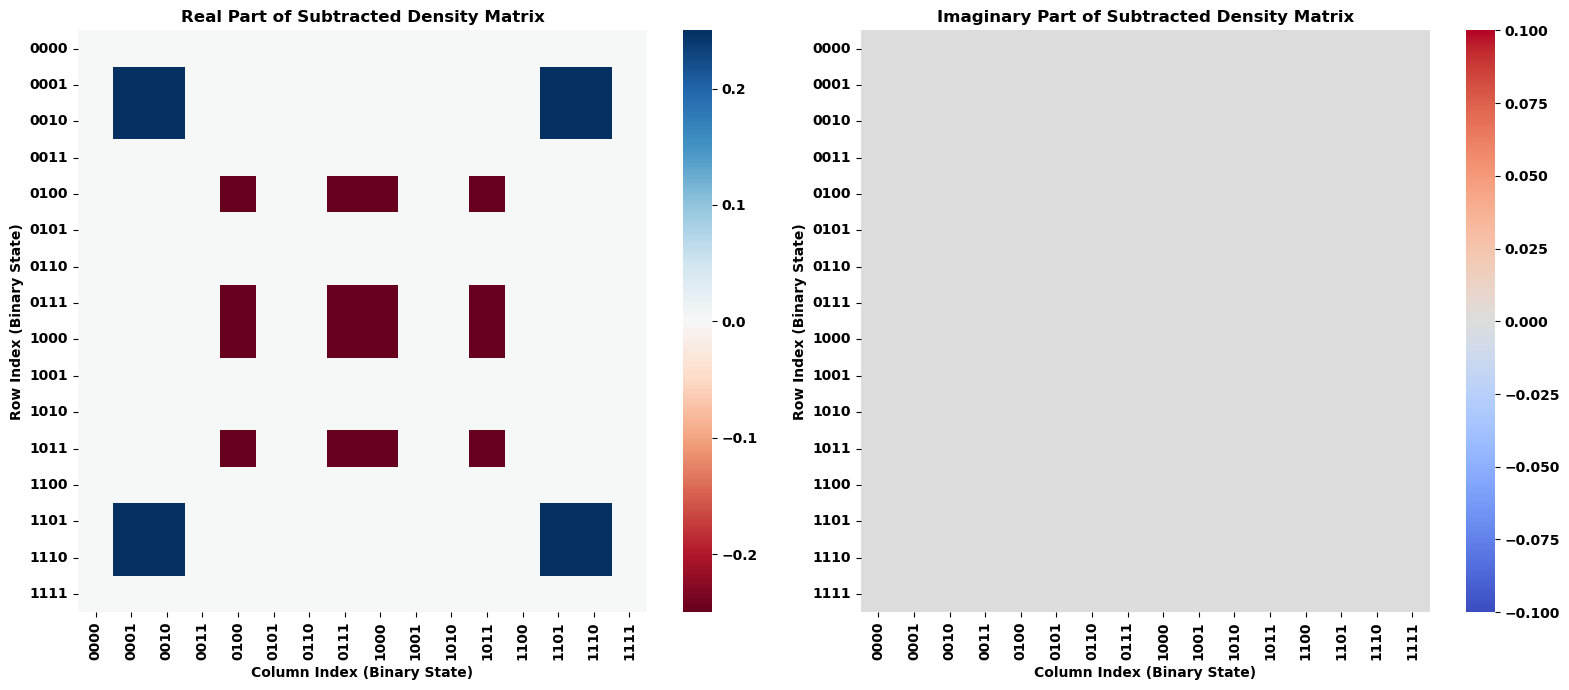

In [57]:
import seaborn as sns
from qiskit.quantum_info import Statevector, DensityMatrix

# Build density matrix from sv0
density_matrix_sv0 = DensityMatrix(sv0)
# Build density matrix from sv
density_matrix_sv = DensityMatrix(sv)
# Subtract the density matrices
subtracted_density_matrix = density_matrix_sv - density_matrix_sv0
# Get the data (a NumPy array of complex numbers)
matrix_data = subtracted_density_matrix.data

# Determine the size of the matrix for labels
dim = matrix_data.shape[0]
labels = [bin(i)[2:].zfill(int(np.log2(dim))) for i in range(dim)] # e.g., '0000', '0001', ...

# Optional: Plotting Real and Imaginary parts separately (also without annotations)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(np.real(matrix_data),
            annot=False, # Set to False
            cmap="RdBu",
            cbar=True,
            xticklabels=labels,
            yticklabels=labels,
            ax=axes[0])
axes[0].set_title("Real Part of Subtracted Density Matrix")
axes[0].set_xlabel("Column Index (Binary State)")
axes[0].set_ylabel("Row Index (Binary State)")

sns.heatmap(np.imag(matrix_data),
            annot=False, # Set to False
            cmap="coolwarm",
            cbar=True,
            xticklabels=labels,
            yticklabels=labels,
            ax=axes[1])
axes[1].set_title("Imaginary Part of Subtracted Density Matrix")
axes[1].set_xlabel("Column Index (Binary State)")
axes[1].set_ylabel("Row Index (Binary State)")

plt.tight_layout()
plt.show()

In [ ]:
threshold = 0.05
row_indices_sv, col_indices_sv = np.where(matrix_to_plot > threshold)
row_indices_sv0, col_indices_sv0 = np.where(matrix_to_plot < -threshold)

labels = [bin(i)[2:].zfill(int(np.log2(dim))) for i in range(dim)] # e.g., '0000', '0001', ...
# Use fancy indexing to get the labels for these row and column indices
row_labels = [labels[i] for i in row_indices_sv]
col_labels = [labels[i] for i in col_indices_sv]
# print(row_labels)
# print(col_labels)

all_labels_set = set(row_labels) | set(col_labels)
sorted_labels = sorted(all_labels_set)

print(sorted_labels)

row_labels = [labels[i] for i in row_indices_sv0]
col_labels = [labels[i] for i in col_indices_sv0]
# print(row_labels)
# print(col_labels)

all_labels_set = set(row_labels) | set(col_labels)
sorted_labels0 = sorted(all_labels_set)

print(sorted_labels0)

Values positive SV: [0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j
 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j]
Values positive SV0: [-0.25+0.j -0.25+0.j -0.25+0.j -0.25+0.j -0.25+0.j -0.25+0.j -0.25+0.j
 -0.25+0.j -0.25+0.j -0.25+0.j -0.25+0.j -0.25+0.j -0.25+0.j -0.25+0.j
 -0.25+0.j -0.25+0.j]


In [ ]:
# The number of qubits for the transformation
num_total_qubits = len(sorted_labels[0])
ng_circ1 = 2 # Based on your initial problem setup
ng_circ2 = 2 # Based on your initial problem setup

all_cnot_configurations = set()

# Your original loop structure with the corrected index transformation
for ibit_string in sorted_labels0:
    for jbit_string in sorted_labels:
        # Correctly find the locations of '1's, transforming indices to qiskit's q0-LSB order
        locations_i_qiskit = [num_total_qubits - 1 - i for i, bit in enumerate(ibit_string) if bit == '1']
        locations_j_qiskit = [num_total_qubits - 1 - i for i, bit in enumerate(jbit_string) if bit == '1']
        
        # Sort the final list for the qn...q0 representation
        locations_i_qiskit.sort(reverse=True)
        locations_j_qiskit.sort(reverse=True)
        
        # Generate CNOT pairs from these locations and add them to the set
        new_cnot_pairs = create_cnot_pairs_from_locations(locations_i_qiskit, locations_j_qiskit)
        all_cnot_configurations.update(new_cnot_pairs)

# Convert the final set to a sorted list for a consistent order
final_cnot_config_list = sorted(list(all_cnot_configurations))

print(f"Total unique CNOT configurations generated: {len(final_cnot_config_list)}")
print(final_cnot_config_list)

In [58]:
# --- Demonstrate Greedy Search ---
print("\n" + "="*40)
print("--- Running Greedy Search ---")
print("="*40)
best_cnot_sequence_greedy, min_kl_greedy = find_best_cnot_sequence(
    circ_bell,
    circ_ghz_ish,
    state_probs_target1_amplitudes,
    state_probs_target2_amplitudes,
    nshots=1000
)

print("\n" + "="*40)
if best_cnot_sequence_greedy:
    print("Greedy Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence_greedy:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_greedy:.6f}")

    # Construct and draw the final best circuit from greedy search
    ng_circ1_for_greedy = circ_bell.num_qubits
    base_combined_circuit_greedy = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_greedy = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_greedy, ng_circ1_for_greedy, best_cnot_sequence_greedy
    )
    print("\n--- Final Optimized Circuit (Greedy) ---")
    print(final_best_circuit_greedy.draw('text'))
else:
    print("Greedy Search: No CNOT configuration sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_greedy:.6f}")
    # Draw the baseline circuit
    base_combined_circuit_greedy = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_greedy = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_greedy, circ_bell.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_greedy.draw('text'))
print("="*40 + "\n")



--- Running Greedy Search ---

--- Starting CNOT Sequence Optimization (Total Qubits: 4) ---
Number of qubits in chunk 1: 2
Number of qubits in chunk 2: 2

Baseline (No CNOTs) KL Sum: 40.060593
Initial best KL sum: 40.060593 (from baseline)

--- Iteration 1: Current Best KL Sum = 40.060593 ---

Iteration 1 improved! Added CNOT: (1, 2)
Current best CNOT sequence: [(1, 2)]
Current minimum combined KL Divergence: 28.873886
Greedy CNOT search took: 1.15 seconds

--- Iteration 2: Current Best KL Sum = 28.873886 ---

Iteration 2 improved! Added CNOT: (2, 0)
Current best CNOT sequence: [(1, 2), (2, 0)]
Current minimum combined KL Divergence: 18.348259
Greedy CNOT search took: 2.12 seconds

--- Iteration 3: Current Best KL Sum = 18.348259 ---

Iteration 3: No further single CNOT additions improved the KL divergence.

Greedy Search Optimal CNOT sequence found:
  q[1] -> q[2]
  q[2] -> q[0]
With minimum combined KL Divergence: 18.348259

--- Final Optimized Circuit (Greedy) ---
              ┌─

In [59]:
print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)

n_epochs = 10
min_greedy_depth = 4

best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_multi_epoch(
    circ_bell,
    circ_ghz_ish,
    state_probs_bell,
    state_probs_ghz_ish,
    state_probs_target1_amplitudes,
    state_probs_target2_amplitudes,
    n_epochs=n_epochs,
    min_cnot_depth=min_greedy_depth,
    nshots=1000,
    threshold=0.05
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ_bell.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ_bell.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running Multi-Epoch Refined Search ---

--- Starting Multi-Epoch Refined Search ---
Number of original CNOT candidates: 8
Number of refined CNOT candidates: 12

--- Starting Epoch 1/10 (Addition) with CNOT: (0, 1) (KL: 30.247729) ---
    --> Found a better KL on this path: 18.258858 at depth 2
    --> Found a better KL on this path: 18.087740 at depth 3
    --> Found a better KL on this path: 9.243043 at depth 4
    --> Found a better KL on this path: 9.122288 at depth 5
    --> Found a better KL on this path: 9.042423 at depth 6
    --> Found a better KL on this path: 0.000338 at depth 7
  Epoch 1 best KL Sum: 0.000338
  --> Epoch 1 found a new overall best KL Sum: 0.000338

--- Starting Epoch 2/10 (Addition) with CNOT: (1, 0) (KL: 29.267050) ---
    --> Found a better KL on this path: 18.978946 at depth 2
    --> Found a better KL on this path: 17.709510 at depth 3
    --> Found a better KL on this path: 9.402620 at depth 4
    --> Found a better KL on this path: 0.000346 at dep

In [60]:
# --- Demonstrate Brute-Force Search ---
print("\n" + "="*40)
print("--- Running Brute-Force Search ---")
print("="*40)
# WARNING: max_cnot_depth grows exponentially! Keep it small (e.g., 1, 2, or 3)
max_brute_force_depth = 4 # Testing up to 2 CNOTs for demonstration

best_cnot_sequence_brute_force, min_kl_brute_force = find_best_cnot_sequence_brute_force(
    circ_bell,
    circ_ghz_ish,
    state_probs_target1_amplitudes,
    state_probs_target2_amplitudes,
    max_cnot_depth=max_brute_force_depth,
    nshots=1000
)

print("\n" + "="*40)
if best_cnot_sequence_brute_force:
    print(f"Brute-Force Search Optimal CNOT sequence (Depth {max_brute_force_depth}) found:")
    for cnot in best_cnot_sequence_brute_force:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_brute_force:.6f}")

    # Construct and draw the final best circuit from brute-force search
    ng_circ1_for_brute_force = circ_bell.num_qubits
    base_combined_circuit_brute_force = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_brute_force = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_brute_force, ng_circ1_for_brute_force, best_cnot_sequence_brute_force
    )
    print("\n--- Final Optimized Circuit (Brute-Force) ---")
    print(final_best_circuit_brute_force.draw('text'))
else:
    print("Brute-Force Search: No CNOT configuration sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_brute_force:.6f}")
    # Draw the baseline circuit
    base_combined_circuit_brute_force = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_brute_force = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_brute_force, circ_bell.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_brute_force.draw('text'))
print("="*40 + "\n")


--- Running Brute-Force Search ---

--- Starting Brute-Force CNOT Sequence Optimization (Total Qubits: 4, Max Depth: 4) ---
Number of qubits in chunk 1: 2
Number of qubits in chunk 2: 2

Baseline (No CNOTs) KL Sum: 40.061141
Initial best KL sum: 40.061141 (from baseline)

--- Testing combinations with 1 CNOTs ---
  --> New best sequence found: [(0, 2)] with KL Sum: 29.013486

--- Testing combinations with 2 CNOTs ---
  --> New best sequence found: [(0, 2), (2, 0)] with KL Sum: 19.209149
  --> New best sequence found: [(0, 2), (3, 0)] with KL Sum: 18.744853
  --> New best sequence found: [(0, 2), (3, 1)] with KL Sum: 17.985921
  --> New best sequence found: [(2, 0), (0, 2)] with KL Sum: 17.845924
  --> New best sequence found: [(1, 3), (2, 1)] with KL Sum: 17.550036

--- Testing combinations with 3 CNOTs ---
  --> New best sequence found: [(2, 0), (0, 2), (3, 0)] with KL Sum: 9.203402
  --> New best sequence found: [(2, 0), (3, 0), (1, 3)] with KL Sum: 9.164132
  --> New best sequence 

findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


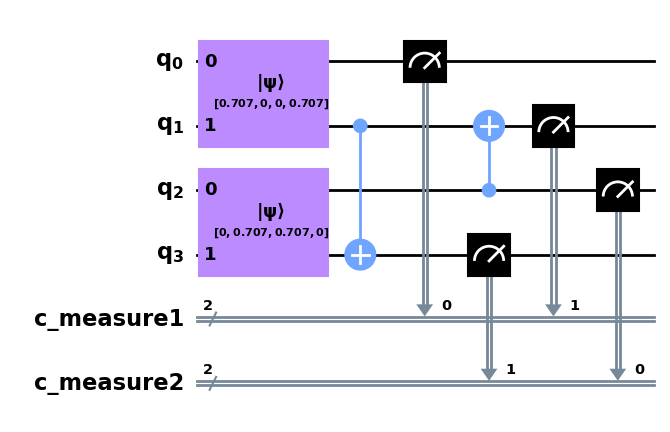

In [9]:
final_best_circuit_greedy.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)


--- Simulating and Plotting Histograms for: Greedy Optimized Circuit ---
Counts for c_measure1: {'10': 522, '00': 479, '11': 525, '01': 474}
Counts for c_measure2: {'01': 522, '10': 479, '00': 525, '11': 474}


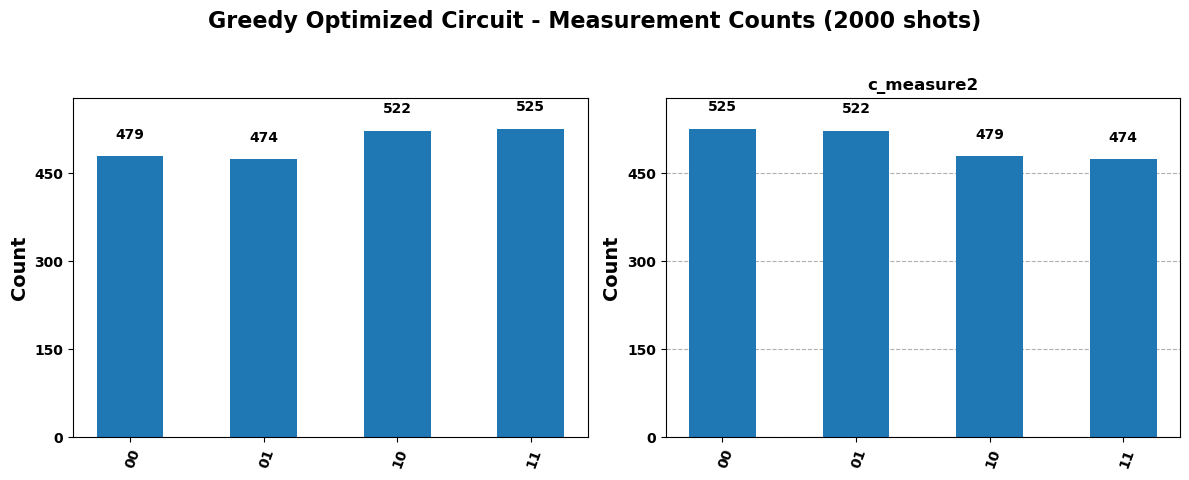

In [10]:
plot_measurement_histograms(final_best_circuit_greedy, nshots=2000, title_prefix="Greedy Optimized Circuit")

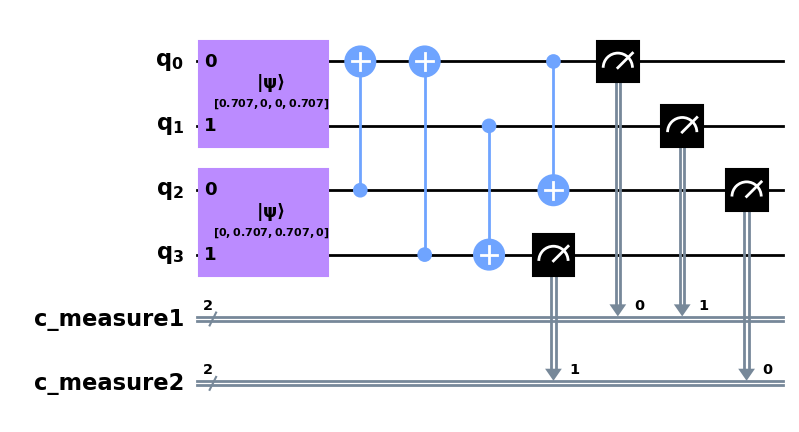

In [11]:
final_best_circuit_brute_force.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)


--- Simulating and Plotting Histograms for: Brute-Force Optimized Circuit ---
Counts for c_measure1: {'01': 513, '10': 487}
Counts for c_measure2: {'00': 508, '11': 492}


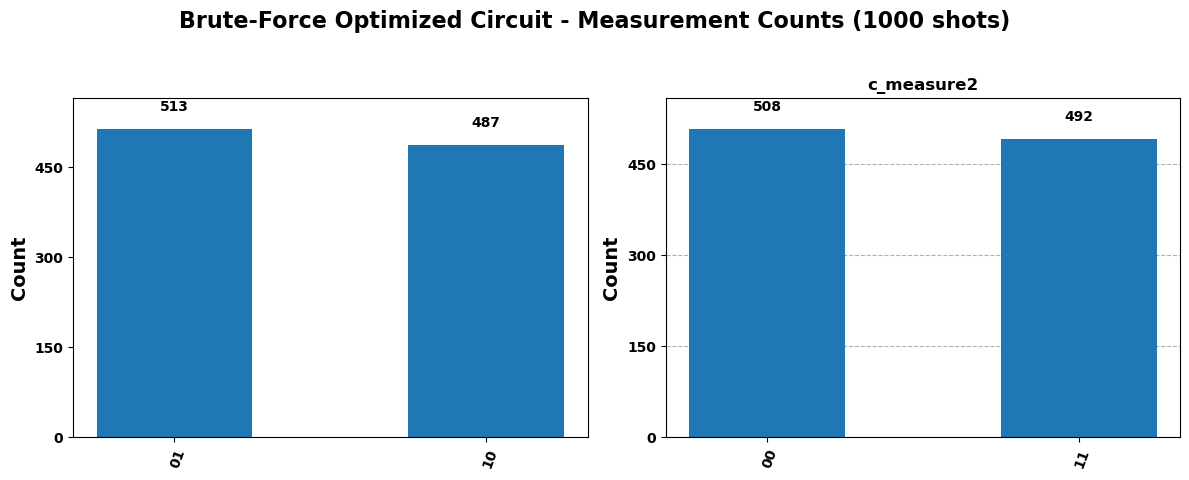

In [12]:
plot_measurement_histograms(final_best_circuit_brute_force, nshots=1000, title_prefix="Brute-Force Optimized Circuit")

In [ ]:
fina .draw(output="mpl", style="clifford", fold=40,  scale = 1.0)


--- Running CRX Angle Optimization (based on Brute-Force CNOT topology) ---

--- Starting CRX Angle Optimization (4 CRX gates) ---

Optimization Results:
  Success: True
  Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  Optimized Angles: ['3.1416', '3.1416', '3.1416', '3.1416']
CRX Angle Optimization took: 18.88 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['3.1416', '3.1416', '3.1416', '3.1416']
  Minimum Combined KL Divergence with Optimized CRX: 0.001769


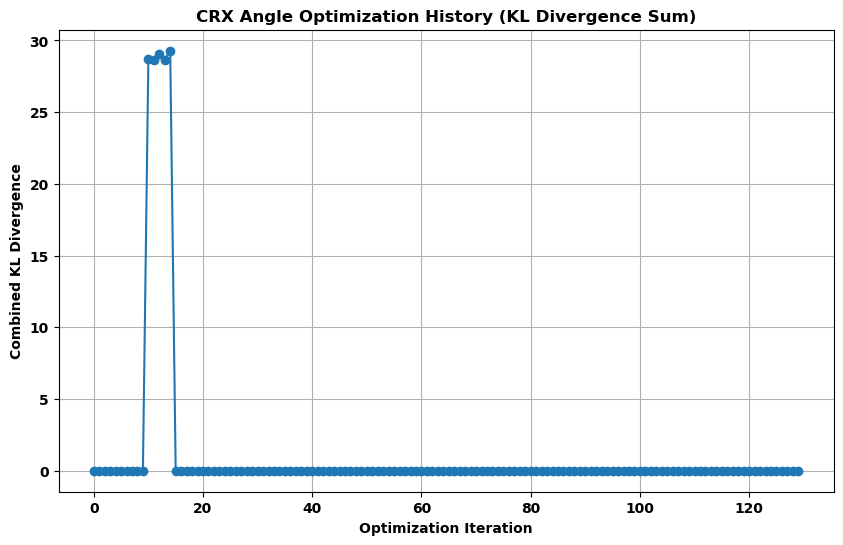


--- Final Optimized Circuit (CRX Angles) ---
              ┌──────────────────────────────────┐┌────────────┐┌────────────┐»
         q_0: ┤0                                 ├┤ Rx(3.1416) ├┤ Rx(3.1416) ├»
              │  Initialize(0.70711,0,0,0.70711) │└─────┬──────┘└─────┬──────┘»
         q_1: ┤1                                 ├──────┼─────────────┼───────»
              ├──────────────────────────────────┤      │             │       »
         q_2: ┤0                                 ├──────■─────────────┼───────»
              │  Initialize(0,0.70711,0.70711,0) │                    │       »
         q_3: ┤1                                 ├────────────────────■───────»
              └──────────────────────────────────┘                            »
c_measure1: 2/════════════════════════════════════════════════════════════════»
                                                                              »
c_measure2: 2/════════════════════════════════════════════════════════════

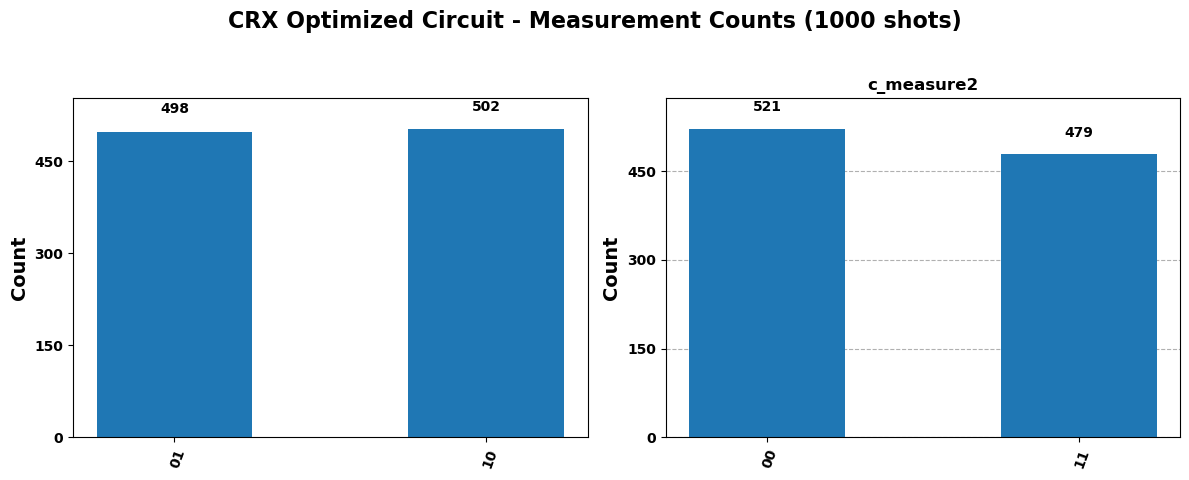

In [22]:
# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on Brute-Force CNOT topology) ---")
print("="*40)
optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ_bell,
    circ_ghz_ish,
    state_probs_target1_amplitudes,
    state_probs_target2_amplitudes,
    best_cnot_sequence_brute_force, # Use the CNOT topology found by brute-force
    nshots=2000,
    etol=1e-4,
    opt_method='L-BFGS-B', # Using L-BFGS-B for angle optimization
    initial_angle_value=np.pi # Start angles at pi (CNOT equivalent)
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish),
    circ_bell.num_qubits,
    best_cnot_sequence_brute_force,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
plot_measurement_histograms(final_crx_optimized_circuit, nshots=1000, title_prefix="CRX Optimized Circuit")

In [3]:
import numpy as np

# --- Function to normalize dictionary values ---
def vector_normalize_dictionary_values(input_dict):
    """Normalizes the values of a dictionary by dividing each value by the L2 norm of all values."""
    values = np.array(list(input_dict.values()), dtype=float)
    if values.size == 0:  # Handle empty dictionary
        return {}
    
    norm_val = np.linalg.norm(values)  # Calculate the L2 norm of the values

    if norm_val == 0:  # Avoid division by zero if all values are zero
        return {key: 0.0 for key in input_dict}

    normalized_dict = {}
    # Iterate through original dictionary items to maintain key order
    for i, (key, value) in enumerate(input_dict.items()):
        normalized_dict[key] = values[i] / norm_val
    return normalized_dict

# --- New Dictionary Definitions ---
# State Set 5a: A simple distribution where states with more '1's have higher values.
state_set_5a_dict = {
    '000': 1,
    '001': 2,
    '010': 2,
    '100': 2,
    '011': 4,
    '101': 4,
    '110': 4,
    '111': 8
}

# State Set 6a: A bell state-like distribution where certain states are highly probable.
# This simulates an entangled state before interaction.
state_set_6a_dict = {
    '0000': 5,
    '0001': 1,
    '0010': 1,
    '0011': 1,
    '0100': 1,
    '0101': 1,
    '0110': 1,
    '0111': 1,
    '1000': 1,
    '1001': 1,
    '1010': 1,
    '1011': 1,
    '1100': 1,
    '1101': 1,
    '1110': 1,
    '1111': 5
}

# Interacted State Set 5a: Simulating a CNOT interaction between qubits 1 and 2
# We increase the probability of entangled states like '011' and '110'.
interacted_state_set_5a_dict = {
    '000': 1,
    '001': 1,
    '010': 1,
    '100': 1,
    '011': 6,
    '101': 2,
    '110': 6,
    '111': 2
}

# Interacted State Set 6a: The bell state distribution is now more focused on states
# that would result from an interaction, such as '0000' and '1111' becoming highly probable.
interacted_state_set_6a_dict = {
    '0000': 8,
    '0001': 1,
    '0010': 1,
    '0011': 1,
    '0100': 1,
    '0101': 1,
    '0110': 1,
    '0111': 1,
    '1000': 1,
    '1001': 1,
    '1010': 1,
    '1011': 1,
    '1100': 1,
    '1101': 1,
    '1110': 1,
    '1111': 8
}

# --- Apply and Print ---
print("--- New Dictionary Definitions ---")
print("State Set 5a:", state_set_5a_dict)
print("State Set 6a:", state_set_6a_dict)
print("Interacted State Set 5a:", interacted_state_set_5a_dict)
print("Interacted State Set 6a:", interacted_state_set_6a_dict)

# Apply vector normalization to the new dictionaries
normalized_state_set_5a_dict_vec = vector_normalize_dictionary_values(state_set_5a_dict)
normalized_state_set_6a_dict_vec = vector_normalize_dictionary_values(state_set_6a_dict)
normalized_interacted_state_set_5a_dict_vec = vector_normalize_dictionary_values(interacted_state_set_5a_dict)
normalized_interacted_state_set_6a_dict_vec = vector_normalize_dictionary_values(interacted_state_set_6a_dict)

print("\n--- Vector Normalized Dictionary Definitions ---")
print("Normalized State Set 5a (Vector Norm):", normalized_state_set_5a_dict_vec)
print("Normalized State Set 6a (Vector Norm):", normalized_state_set_6a_dict_vec)
print("Normalized Interacted State Set 5a (Vector Norm):", normalized_interacted_state_set_5a_dict_vec)
print("Normalized Interacted State Set 6a (Vector Norm):", normalized_interacted_state_set_6a_dict_vec)
# 1. Define initial circuits for concatenation
circ1 = create_initial_circuit2(normalized_state_set_5a_dict_vec)
circ2 = create_initial_circuit2(normalized_state_set_6a_dict_vec)

--- New Dictionary Definitions ---
State Set 5a: {'000': 1, '001': 2, '010': 2, '100': 2, '011': 4, '101': 4, '110': 4, '111': 8}
State Set 6a: {'0000': 5, '0001': 1, '0010': 1, '0011': 1, '0100': 1, '0101': 1, '0110': 1, '0111': 1, '1000': 1, '1001': 1, '1010': 1, '1011': 1, '1100': 1, '1101': 1, '1110': 1, '1111': 5}
Interacted State Set 5a: {'000': 1, '001': 1, '010': 1, '100': 1, '011': 6, '101': 2, '110': 6, '111': 2}
Interacted State Set 6a: {'0000': 8, '0001': 1, '0010': 1, '0011': 1, '0100': 1, '0101': 1, '0110': 1, '0111': 1, '1000': 1, '1001': 1, '1010': 1, '1011': 1, '1100': 1, '1101': 1, '1110': 1, '1111': 8}

--- Vector Normalized Dictionary Definitions ---
Normalized State Set 5a (Vector Norm): {'000': 0.08944271909999159, '001': 0.17888543819998318, '010': 0.17888543819998318, '100': 0.17888543819998318, '011': 0.35777087639996635, '101': 0.35777087639996635, '110': 0.35777087639996635, '111': 0.7155417527999327}
Normalized State Set 6a (Vector Norm): {'0000': 0.625, '00

In [26]:
def _run_consecutive_pairwise_removal_search(
    base_combined_circuit,
    num_qubits,
    state_vec_probs_target1,
    state_vec_probs_target2,
    full_cnot_candidates,
    best_sequence_so_far,
    baseline_kl_sum,
    nshots
):
    """
    Evaluates which CNOT *pairs* from the working pool (full_cnot_candidates - best_sequence_so_far)
    can be removed (excluded from consideration in future additions) to reduce KL divergence.

    `best_sequence_so_far` remains fixed and is not changed in this function.

    Returns:
        - working_pool: reduced list of CNOTs to try in future additions.
        - kl_sum: best achieved KL divergence during removal pruning.
    """

    # Initialize working pool: everything not already part of best sequence
    working_pool = list(set(full_cnot_candidates) - set(best_sequence_so_far))
    current_kl_sum = baseline_kl_sum

    print(f"  Starting removal search with {len(working_pool)} CNOTs in working pool")
    print(f"   - Initial worst KL: {baseline_kl_sum:.6f}.")
    best_pair_to_remove = None
    best_kl_after_removal = current_kl_sum

    # Evaluate all pair removals
    n_perm = 0
    #for cnot_pair_to_remove in itertools.combinations(working_pool, 2):
    for cnot_pair_to_remove in itertools.permutations(working_pool, 2): 
        n_perm += 1
        trial_pool = [c for c in working_pool if c not in cnot_pair_to_remove]
        trial_sequence = best_sequence_so_far + trial_pool

        trial_circuit = add_cnots_and_measurements_to_circuit(
            base_combined_circuit, num_qubits, trial_sequence
        )
        kl_divs = score_circuit_kl_divergences(
            trial_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots
        )
        n_perm += 1
        if kl_divs is not None:
            kl_sum = kl_divs[0] + kl_divs[1]
            if kl_sum < best_kl_after_removal:
                best_kl_after_removal = kl_sum
                best_pair_to_remove = cnot_pair_to_remove

    print("  Number of tested permutations for bad pair candidates are ", str(n_perm))

    if best_pair_to_remove is not None:
        working_pool = [c for c in working_pool if c not in best_pair_to_remove]
        current_kl_sum = best_kl_after_removal
        print(f"  Removed pair {best_pair_to_remove}. New KL: {current_kl_sum:.6f}. Pool size: {len(working_pool)}")
    else:
        print("  No removable pair found that reduces KL. Working pool unchanged.")

    return working_pool

def find_best_cnot_sequence_iterative_pairwise(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_probs_initial1: dict,
    state_probs_initial2: dict,
    state_vec_probs_target1: dict,
    state_vec_probs_target2: dict,
    nshots: int = 1000,
    threshold: float = 0.05
):
    """
    Performs an iterative optimization loop:
    1. Starts from empty CNOT sequence.
    2. Adds best CNOT pairs that reduce KL divergence.
    3. Then prunes worst CNOT pairs that don't help.
    """
    import time

    ng_circ1 = circ1.num_qubits
    KL_TOLERANCE = 0.00005

    print(f"\n--- Starting Iterative Pairwise Search ---")
    start_total_time = time.time()

    # --- Build refined CNOT candidate list ---
    state_list1_initial, _ = _process_target_state_input(state_probs_initial1)
    state_list2_initial, _ = _process_target_state_input(state_probs_initial2)
    state_list1_target, _ = _process_target_state_input(state_vec_probs_target1)
    state_list2_target, _ = _process_target_state_input(state_vec_probs_target2)

    combined_state_amplitudes0 = np.kron(state_list2_initial, state_list1_initial)
    combined_state_amplitudes = np.kron(state_list2_target, state_list1_target)
    sv0 = Statevector(combined_state_amplitudes0)
    sv = Statevector(combined_state_amplitudes)

    dm0 = DensityMatrix(sv0)
    dm = DensityMatrix(sv)
    diff = dm - dm0
    matrix_data = diff.data

    row_indices, col_indices = np.where(matrix_data > threshold)
    row_indices0, col_indices0 = np.where(matrix_data < -threshold)

    dim = matrix_data.shape[0]
    labels = [bin(i)[2:].zfill(int(np.log2(dim))) for i in range(dim)]
    active_labels = set(labels[i] for i in row_indices) | set(labels[i] for i in col_indices)
    inactive_labels = set(labels[i] for i in row_indices0) | set(labels[i] for i in col_indices0)

    all_cnot_configurations = set()
    for ibit_string in inactive_labels:
        for jbit_string in active_labels:
            i_locs = [len(ibit_string) - 1 - i for i, bit in enumerate(ibit_string) if bit == '1']
            j_locs = [len(jbit_string) - 1 - i for i, bit in enumerate(jbit_string) if bit == '1']
            all_cnot_configurations.update(create_cnot_pairs_from_locations(i_locs, j_locs))
    all_possible_single_cnots = sorted(list(all_cnot_configurations))

    print(f"Number of refined CNOT candidates: {len(all_possible_single_cnots)}")

    # --- Baseline (no CNOTs) ---
    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit = add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, [])
    kl_divs = score_circuit_kl_divergences(base_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots)
    initial_kl_sum = kl_divs[0] + kl_divs[1] if kl_divs is not None else float('inf')

    best_sequence = []
    best_kl_sum = initial_kl_sum

    if len(all_possible_single_cnots) < 2:
        print("Not enough CNOT candidates to form a pair. Skipping search.")
        return [], initial_kl_sum

    # --- Main loop ---
    last_kl_sum = best_kl_sum + 1
    iteration = 0

    working_pool = all_possible_single_cnots
    while best_kl_sum < last_kl_sum:
        iteration += 1
        last_kl_sum = best_kl_sum
        print(f"\n--- Iteration {iteration} (Depth: {len(best_sequence)}, KL: {best_kl_sum:.6f}) ---")

        # --- Add best pair ---
        print("  - Starting pairwise addition phase -")
        remaining = [c for c in working_pool if c not in best_sequence]
        if len(remaining) < 2:
            print("  Not enough remaining CNOTs to form a pair. Ending addition phase.")
            break

        best_pair = None
        min_kl_after_add = float('inf')

        n_perm = 0
        for pair in itertools.permutations(remaining, 2): 
            n_perm += 1
            trial_sequence = best_sequence + list(pair)
            trial_circuit = add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, trial_sequence)
            kl_divs = score_circuit_kl_divergences(trial_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots)
            if kl_divs is not None:
                kl_sum = kl_divs[0] + kl_divs[1]
                if kl_sum < min_kl_after_add:
                    best_pair = list(pair)
                    min_kl_after_add = kl_sum

        print("  Number of tested permutations for good pair candidates are ", str(n_perm))
        
        if best_pair is not None and min_kl_after_add < best_kl_sum - KL_TOLERANCE:
            best_sequence += best_pair
            best_kl_sum = min_kl_after_add
            print(f"  Added pair {best_pair}. New KL Sum: {best_kl_sum:.6f}")
        else:
            print("  No pair improved KL. Ending search.")
            break

        # --- Try to prune ---
        if len(best_sequence) >= 2:
            print("  - Starting consecutive pairwise removal phase -")
            all_cnot_circuit = add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, working_pool)
            kl_divs_full = score_circuit_kl_divergences(all_cnot_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots)
            full_kl_sum = kl_divs_full[0] + kl_divs_full[1] if kl_divs_full is not None else float('inf')

            working_pool = _run_consecutive_pairwise_removal_search(
                base_combined_circuit, ng_circ1, state_vec_probs_target1, state_vec_probs_target2,
                working_pool, best_sequence, full_kl_sum, nshots
            )
        else:
            print("  Skipping removal (not enough CNOTs).")

    end_time = time.time()
    print(f"\nTotal search time: {end_time - start_total_time:.2f} seconds.")
    return best_sequence, best_kl_sum, all_possible_single_cnots, working_pool
    #if len(all_possible_single_cnots) < 2:
    #    print("Not enough CNOT candidates to form a pair. Skipping search.")
    #    return [], initial_kl_sum, all_possible_single_cnots, working_pool # Corrected line


In [5]:
print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)
    
best_cnot_sequence, min_kl_sum, all_possible_single_cnots, working_pool = find_best_cnot_sequence_iterative_pairwise(
    circ1,
    circ2,
    normalized_state_set_5a_dict_vec,
    normalized_state_set_6a_dict_vec,
    normalized_interacted_state_set_5a_dict_vec,
    normalized_interacted_state_set_6a_dict_vec,
    nshots=2000,
    threshold=0.05
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running Multi-Epoch Refined Search ---

--- Starting Iterative Pairwise Search ---
Number of refined CNOT candidates: 42

--- Iteration 1 (Depth: 0, KL: 1.141042) ---
  - Starting pairwise addition phase -
  Number of tested permutations for good pair candidates are  1722
  Added pair [(6, 2), (2, 0)]. New KL Sum: 0.328566
  - Starting consecutive pairwise removal phase -
  Starting removal search with 40 CNOTs in working pool
   - Initial worst KL: 2.829809.
  Number of tested permutations for bad pair candidates are  3120
  Removed pair ((3, 6), (5, 2)). New KL: 2.053130. Pool size: 38

--- Iteration 2 (Depth: 2, KL: 0.328566) ---
  - Starting pairwise addition phase -
  Number of tested permutations for good pair candidates are  1406
  No pair improved KL. Ending search.

Total search time: 777.58 seconds.

Multi-Epoch Search Optimal CNOT sequence found:
  q[6] -> q[2]
  q[2] -> q[0]
With minimum combined KL Divergence: 0.328566

--- Final Optimized Circuit ---
              »



--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (2 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['2.5568', '2.4791']
CRX Angle Optimization took: 7.21 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['2.5568', '2.4791']
  Minimum Combined KL Divergence with Optimized CRX: 0.391124


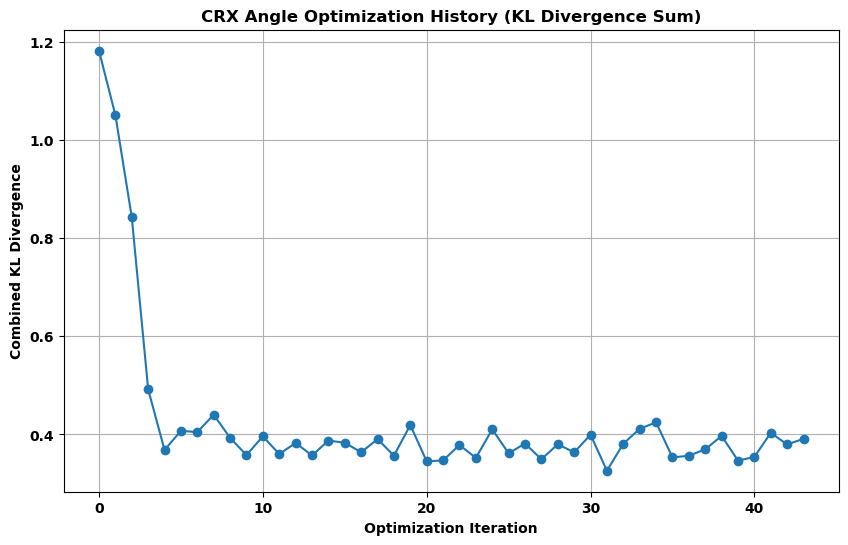


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
c_measure1: 3/»
              »
c_measure2: 4/»
              »
«                             ┌───────────────────────────────────────────────────────────────────────────────┐                »
«         q_0: ───────────────┤0                                                                              ├────────────────»
«                             │                                                                               │                »
«         q_1: ───────────────┤1 Initialize(0.089443,0.17889,0.17889,0.35777,0.17889,0.35777,0.35777,0.71554) ├────────────────»
«                             │                                                                               │                »
«    

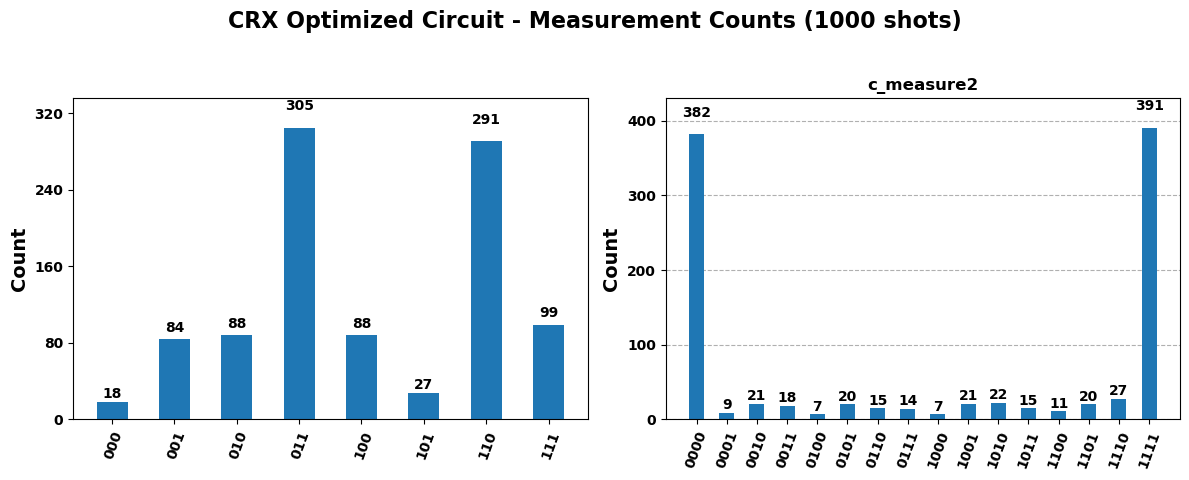

In [6]:
# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)
optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_interacted_state_set_5a_dict_vec,
    normalized_interacted_state_set_6a_dict_vec,
    best_cnot_sequence, # Use the CNOT topology found by brute-force
    nshots=2000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= 0 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
plot_measurement_histograms(final_crx_optimized_circuit, nshots=1000, title_prefix="CRX Optimized Circuit")


--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (38 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['1.0793', '0.0280', '0.2465', '0.8286', '0.1200', '0.0026', '0.0346', '0.9230', '0.0010', '0.9964', '0.1792', '0.0053', '0.0524', '0.1994', '0.0000', '0.0032', '-0.0000', '0.8899', '0.0001', '0.0023', '0.0010', '0.0009', '0.0001', '0.0025', '0.0009', '0.0031', '0.0129', '0.0001', '0.0006', '0.0001', '0.0000', '0.0008', '0.0007', '0.0004', '0.0000', '0.0000', '0.0000', '0.0000']
CRX Angle Optimization took: 77.82 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['1.0793', '0.0280', '0.2465', '0.8286', '0.1200', '0.0026', '0.0346', '0.9230', '0.0010', '0.9964', '0.1792', '0.0053', '0.0524', '0.1994', '0.0000', '0.0032', '-0.0000', '0.8899', '0.0001', '0.0023', '0.0010', '0.0009', '0.0001', '0.0025', '0.0009', '0.0031', '0.0129', '0.0001', '0.0006', '

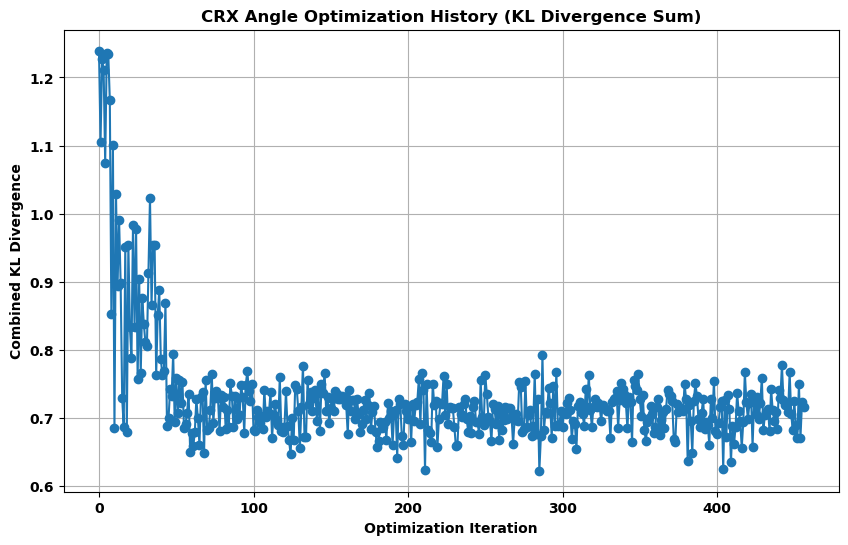


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
c_measure1: 3/»
              »
c_measure2: 4/»
              »
«                             ┌───────────────────────────────────────────────────────────────────────────────┐                »
«         q_0: ───────────────┤0                                                                              ├────────────────»
«                             │                                                                               │                »
«         q_1: ───────────────┤1 Initialize(0.089443,0.17889,0.17889,0.35777,0.17889,0.35777,0.35777,0.71554) ├────────────────»
«                             │                                                                               │                »
«    

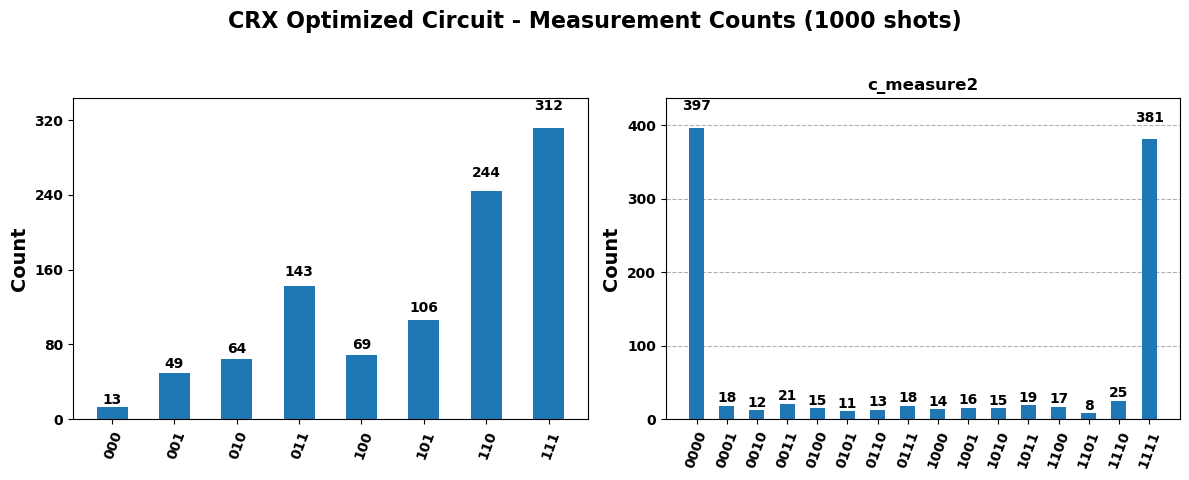

In [7]:
# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)
optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_interacted_state_set_5a_dict_vec,
    normalized_interacted_state_set_6a_dict_vec,
    working_pool, # Use the CNOT topology found by brute-force
    nshots=2000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value = 0 # Start angles at pi (CNOT equivalent)
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    working_pool,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
plot_measurement_histograms(final_crx_optimized_circuit, nshots=1000, title_prefix="CRX Optimized Circuit")

In [3]:
import numpy as np
import pandas as pd
import scanpy as sc 

np.random.seed(42) 

adata = sc.read_h5ad("dataset_co_mo2.h5ad")
# Data prep
sc.pp.normalize_total(adata, target_sum=1e4) # You can adjust target_sum # Seems not to help
sc.pp.log1p(adata)

In [4]:
gl_source = ['STAT3','IL6RorST','TGFBR1or2','PDGFB'] # All values from the first column
gl_recv =['PDGFRB', 'TGFB1', 'IL6']  # All values from the second column

In [5]:
ict1 = adata.obs["BatchID"] == "Cancer Cells (Co)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Co)" 

adata_ct1_co = adata[ict1, gl_source]
adata_ct2_co = adata[ict2, gl_recv]
#adata_ct1_co = sc.external.pp.magic(adata_ct1_co, name_list=gl_source, knn=5, random_state=42)
#adata_ct2_co = sc.external.pp.magic(adata_ct2_co, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_co)
print(adata_ct2_co)

Xct1_co = adata_ct1_co.X.toarray()
Xct2_co = adata_ct2_co.X.toarray()
#Xct1_co = adata_ct1_co.X
#Xct2_co = adata_ct2_co.X

# Assuming Xct1_co and Xct2 are your log-transformed expression matrices
Xct1means = np.mean(Xct1_co, axis=0) *0
Xct2means = np.mean(Xct2_co, axis=0) *0
print("CT1 (Co) mean expression:", Xct1means)
print("CT2 (Co) mean expression:", Xct2means)

# Binarize Xct1
Xct1_binary_co = (Xct1_co > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_co = (Xct2_co > Xct2means).astype(int)


View of AnnData object with n_obs × n_vars = 1414 × 4
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
View of AnnData object with n_obs × n_vars = 1324 × 3
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
CT1 (Co) mean expression: [0. 0. 0. 0.]
CT2 (Co) mean expression: [0. 0. 0.]


In [6]:
ict1 = adata.obs["BatchID"] == "Cancer Cells (Mo)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Mo)" 

adata_ct1_mo = adata[ict1, gl_source]
adata_ct2_mo = adata[ict2, gl_recv]
#adata_ct1_mo = sc.external.pp.magic(adata_ct1_mo, name_list=gl_source, knn=5, random_state=42)
#adata_ct2_mo = sc.external.pp.magic(adata_ct2_mo, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_mo)
print(adata_ct2_mo)

# Library size normalization 
Xct1_mo = adata_ct1_mo.X.toarray()
Xct2_mo = adata_ct2_mo.X.toarray()
#Xct1_mo = adata_ct1_mo.X
#Xct2_mo = adata_ct2_mo.X

# Utilize the mono cultured means here
# Binarize Xct1
Xct1_binary_mo = (Xct1_mo > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_mo = (Xct2_mo > Xct2means).astype(int)

View of AnnData object with n_obs × n_vars = 2364 × 4
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
View of AnnData object with n_obs × n_vars = 2788 × 3
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'


In [7]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from histogram_functions import create_joint_histogram, plot_joint_histogram, create_percent_joint_histogram, count_boolean_vector_occurrences

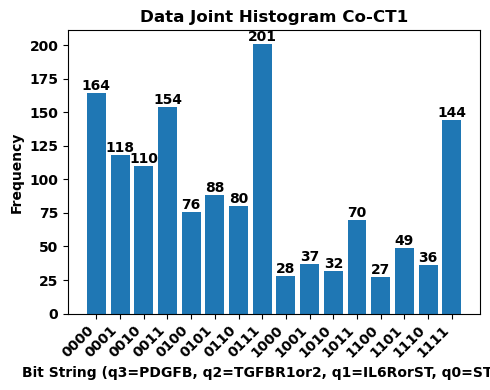

Joint Counts: Counter({'0111': 201, '0000': 164, '0011': 154, '1111': 144, '0001': 118, '0010': 110, '0101': 88, '0110': 80, '0100': 76, '1011': 70, '1101': 49, '1001': 37, '1110': 36, '1010': 32, '1000': 28, '1100': 27})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [8]:
joint_counts_ct1_co, bit_strings_ct1_co = create_joint_histogram(Xct1_binary_co)
#joint_counts_ct1_co, bit_strings_ct1_co = create_percent_joint_histogram(Xct1_binary_co)

num_qubits = Xct1_binary_co.shape[1] 
plot_joint_histogram(joint_counts_ct1_co, num_qubits = num_qubits, features=gl_source, figsize = (5,4), filename = 'joint_counts_co_ct1.svg', title='Data Joint Histogram Co-CT1' )  # Pass num_qubits
#plot_joint_histogram(histogram_data, figsize=(5,4), filename = 'hist_cc_3_4pi.svg', title= r'Histogram $Ry(3\pi/4)$' )

print("Joint Counts:", joint_counts_ct1_co)
print("Bit Strings:", bit_strings_ct1_co)

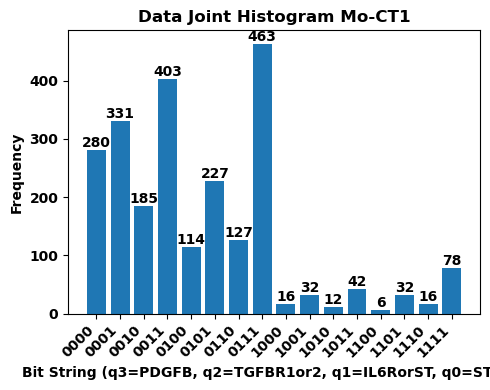

Joint Counts: Counter({'0111': 463, '0011': 403, '0001': 331, '0000': 280, '0101': 227, '0010': 185, '0110': 127, '0100': 114, '1111': 78, '1011': 42, '1101': 32, '1001': 32, '1110': 16, '1000': 16, '1010': 12, '1100': 6})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [9]:
joint_counts_ct1_mo, bit_strings_ct1_mo = create_joint_histogram(Xct1_binary_mo)
#joint_counts_ct1_mo, bit_strings_ct1_mo = create_percent_joint_histogram(Xct1_binary_mo)

num_qubits = Xct1_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct1_mo, num_qubits = num_qubits, features=gl_source, figsize = (5,4), filename = 'joint_counts_mo_ct1.svg', title='Data Joint Histogram Mo-CT1' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct1_mo)
print("Bit Strings:", bit_strings_ct1_mo)

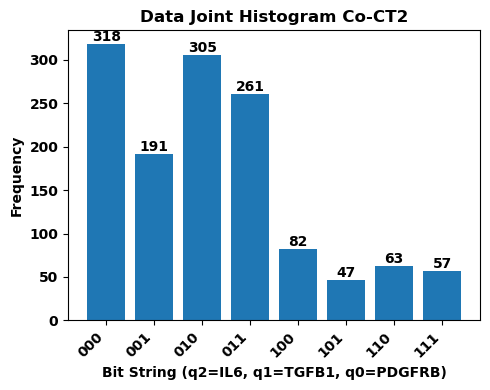

Joint Counts: Counter({'000': 318, '010': 305, '011': 261, '001': 191, '100': 82, '110': 63, '111': 57, '101': 47})
Bit Strings: ['000', '001', '010', '011', '100', '101', '110', '111']


In [10]:
joint_counts_ct2_co, bit_strings_ct2_co = create_joint_histogram(Xct2_binary_co)
#joint_counts_ct2_co, bit_strings_ct2_co = create_percent_joint_histogram(Xct2_binary_co)

num_qubits2 = Xct2_binary_co.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_co, num_qubits = num_qubits2, features=gl_recv, figsize = (5,4), filename = 'joint_counts_co_ct2.svg', title='Data Joint Histogram Co-CT2' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_co)
print("Bit Strings:", bit_strings_ct2_co)

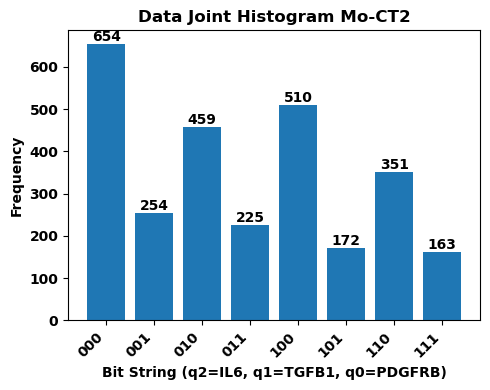

Joint Counts: Counter({'000': 654, '100': 510, '010': 459, '110': 351, '001': 254, '011': 225, '101': 172, '111': 163})
Bit Strings: ['000', '001', '010', '011', '100', '101', '110', '111']


In [11]:
joint_counts_ct2_mo, bit_strings_ct2_mo = create_joint_histogram(Xct2_binary_mo)
#joint_counts_ct2_mo, bit_strings_ct2_mo = create_percent_joint_histogram(Xct2_binary_mo)

num_qubits2 = Xct2_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_mo, num_qubits = num_qubits2, features=gl_recv, figsize = (5,4), filename = 'joint_counts_mo_ct2.svg', title='Data Joint Histogram Mo-CT2' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_mo)
print("Bit Strings:", bit_strings_ct2_mo)

In [12]:
import numpy as np
# --- Function to normalize dictionary values ---
def vector_normalize_dictionary_values(input_dict):
    """Normalizes the values of a dictionary by dividing each value by the L2 norm of all values."""
    values = np.array(list(input_dict.values()), dtype=float)
    if values.size == 0:  # Handle empty dictionary
        return {}
    
    norm_val = np.linalg.norm(values)  # Calculate the L2 norm of the values

    if norm_val == 0:  # Avoid division by zero if all values are zero
        return {key: 0.0 for key in input_dict}

    normalized_dict = {}
    # Iterate through original dictionary items to maintain key order
    for i, (key, value) in enumerate(input_dict.items()):
        normalized_dict[key] = values[i] / norm_val
    return normalized_dict

# --- Apply and Print ---
print("--- New Dictionary Definitions ---")
print("State Set CT1 MO:", joint_counts_ct1_mo)
print("State Set CT2 MO:", joint_counts_ct2_mo)
print("Interacted State Set CT1 CO:", joint_counts_ct1_co)
print("Interacted State Set CT2 CO:", joint_counts_ct2_co)

# Apply vector normalization to the new dictionaries
normalized_joint_counts_ct1_mo = vector_normalize_dictionary_values(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = vector_normalize_dictionary_values(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = vector_normalize_dictionary_values(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = vector_normalize_dictionary_values(joint_counts_ct2_co)

print("\n--- Vector Normalized Dictionary Definitions ---")
print("Normalized State Set 5a (Vector Norm):", normalized_joint_counts_ct1_mo)
print("Normalized State Set 6a (Vector Norm):", normalized_joint_counts_ct2_mo)
print("Normalized Interacted State Set 5a (Vector Norm):", normalized_joint_counts_ct1_co)
print("Normalized Interacted State Set 6a (Vector Norm):", normalized_joint_counts_ct2_co)
# 1. Define initial circuits for concatenation
circ1 = create_initial_circuit2(normalized_joint_counts_ct1_mo)
circ2 = create_initial_circuit2(normalized_joint_counts_ct2_mo)

--- New Dictionary Definitions ---
State Set CT1 MO: Counter({'0111': 463, '0011': 403, '0001': 331, '0000': 280, '0101': 227, '0010': 185, '0110': 127, '0100': 114, '1111': 78, '1011': 42, '1101': 32, '1001': 32, '1110': 16, '1000': 16, '1010': 12, '1100': 6})
State Set CT2 MO: Counter({'000': 654, '100': 510, '010': 459, '110': 351, '001': 254, '011': 225, '101': 172, '111': 163})
Interacted State Set CT1 CO: Counter({'0111': 201, '0000': 164, '0011': 154, '1111': 144, '0001': 118, '0010': 110, '0101': 88, '0110': 80, '0100': 76, '1011': 70, '1101': 49, '1001': 37, '1110': 36, '1010': 32, '1000': 28, '1100': 27})
Interacted State Set CT2 CO: Counter({'000': 318, '010': 305, '011': 261, '001': 191, '100': 82, '110': 63, '111': 57, '101': 47})

--- Vector Normalized Dictionary Definitions ---
Normalized State Set 5a (Vector Norm): {'0000': 0.3370300821070177, '0111': 0.557303314341247, '0101': 0.2732351022796179, '1111': 0.09388695144409778, '0110': 0.15286721581282586, '0001': 0.39841

In [13]:
def _run_consecutive_pairwise_removal_search(
    base_combined_circuit,
    num_qubits,
    state_vec_probs_target1,
    state_vec_probs_target2,
    full_cnot_candidates,
    best_sequence_so_far,
    baseline_kl_sum,
    nshots
):
    """
    Evaluates which CNOT *pairs* from the working pool (full_cnot_candidates - best_sequence_so_far)
    can be removed (excluded from consideration in future additions) to reduce KL divergence.

    `best_sequence_so_far` remains fixed and is not changed in this function.

    Returns:
        - working_pool: reduced list of CNOTs to try in future additions.
        - kl_sum: best achieved KL divergence during removal pruning.
    """

    # Initialize working pool: everything not already part of best sequence
    working_pool = list(set(full_cnot_candidates) - set(best_sequence_so_far))
    current_kl_sum = baseline_kl_sum

    print(f"  Starting removal search with {len(working_pool)} CNOTs in working pool")
    print(f"   - Initial worst KL: {baseline_kl_sum:.6f}.")
    best_pair_to_remove = None
    best_kl_after_removal = current_kl_sum

    # Evaluate all pair removals
    n_perm = 0
    for cnot_pair_to_remove in itertools.permutations(working_pool, 2): 
    #for cnot_pair_to_remove in itertools.combinations(working_pool, 2):
        n_perm += 1
        trial_pool = [c for c in working_pool if c not in cnot_pair_to_remove]
        trial_sequence = best_sequence_so_far + trial_pool

        trial_circuit = add_cnots_and_measurements_to_circuit(
            base_combined_circuit, num_qubits, trial_sequence
        )
        kl_divs = score_circuit_kl_divergences(
            trial_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots
        )
        n_perm += 1
        if kl_divs is not None:
            kl_sum = kl_divs[0] + kl_divs[1]
            if kl_sum < best_kl_after_removal:
                best_kl_after_removal = kl_sum
                best_pair_to_remove = cnot_pair_to_remove

    print("  Number of tested permutations for bad pair candidates are ", str(n_perm))

    if best_pair_to_remove is not None:
        working_pool = [c for c in working_pool if c not in best_pair_to_remove]
        current_kl_sum = best_kl_after_removal
        print(f"  Removed pair {best_pair_to_remove}. New KL: {current_kl_sum:.6f}. Pool size: {len(working_pool)}")
    else:
        print("  No removable pair found that reduces KL. Working pool unchanged.")

    return working_pool

def find_best_cnot_sequence_iterative_pairwise(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_probs_initial1: dict,
    state_probs_initial2: dict,
    state_vec_probs_target1: dict,
    state_vec_probs_target2: dict,
    nshots: int = 1000,
    threshold: float = 0.05
):
    """
    Performs an iterative optimization loop:
    1. Starts from empty CNOT sequence.
    2. Adds best CNOT pairs that reduce KL divergence.
    3. Then prunes worst CNOT pairs that don't help.
    """
    import time

    ng_circ1 = circ1.num_qubits
    KL_TOLERANCE = 0.00005

    print(f"\n--- Starting Iterative Pairwise Search ---")
    start_total_time = time.time()

    # --- Build refined CNOT candidate list ---
    state_list1_initial, _ = _process_target_state_input(state_probs_initial1)
    state_list2_initial, _ = _process_target_state_input(state_probs_initial2)
    state_list1_target, _ = _process_target_state_input(state_vec_probs_target1)
    state_list2_target, _ = _process_target_state_input(state_vec_probs_target2)

    combined_state_amplitudes0 = np.kron(state_list2_initial, state_list1_initial)
    combined_state_amplitudes = np.kron(state_list2_target, state_list1_target)
    sv0 = Statevector(combined_state_amplitudes0)
    sv = Statevector(combined_state_amplitudes)

    dm0 = DensityMatrix(sv0)
    dm = DensityMatrix(sv)
    diff = dm - dm0
    matrix_data = diff.data

    row_indices, col_indices = np.where(matrix_data > threshold)
    row_indices0, col_indices0 = np.where(matrix_data < -threshold)

    dim = matrix_data.shape[0]
    labels = [bin(i)[2:].zfill(int(np.log2(dim))) for i in range(dim)]
    active_labels = set(labels[i] for i in row_indices) | set(labels[i] for i in col_indices)
    active_labels0 = set(labels[i] for i in row_indices0) | set(labels[i] for i in col_indices0)

    all_cnot_configurations = set()
    for ibit_string in active_labels0:
        for jbit_string in active_labels:
            i_locs = [len(ibit_string) - 1 - i for i, bit in enumerate(ibit_string) if bit == '1']
            j_locs = [len(jbit_string) - 1 - i for i, bit in enumerate(jbit_string) if bit == '1']
            all_cnot_configurations.update(create_cnot_pairs_from_locations(i_locs, j_locs))
    all_possible_single_cnots = sorted(list(all_cnot_configurations))

    print(f"Number of refined CNOT candidates: {len(all_possible_single_cnots)}")

    # Optional: Plotting Real and Imaginary parts separately (also without annotations)
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    sns.heatmap(np.real(matrix_data),
                annot=False, # Set to False
                cmap="RdBu",
                cbar=True,
                xticklabels=labels,
                yticklabels=labels,
                ax=axes[0])
    axes[0].set_title("Real Part of Subtracted Density Matrix")
    axes[0].set_xlabel("Column Index (Binary State)")
    axes[0].set_ylabel("Row Index (Binary State)")

    sns.heatmap(np.imag(matrix_data),
                annot=False, # Set to False
                cmap="coolwarm",
                cbar=True,
                xticklabels=labels,
                yticklabels=labels,
                ax=axes[1])
    axes[1].set_title("Imaginary Part of Subtracted Density Matrix")
    axes[1].set_xlabel("Column Index (Binary State)")
    axes[1].set_ylabel("Row Index (Binary State)")

    plt.tight_layout()
    plt.savefig('dens_state_diff.svg')

    # --- Baseline (no CNOTs) ---
    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit = add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, [])
    kl_divs = score_circuit_kl_divergences(base_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots)
    initial_kl_sum = kl_divs[0] + kl_divs[1] if kl_divs is not None else float('inf')

    best_sequence = []
    best_kl_sum = initial_kl_sum

    if len(all_possible_single_cnots) < 2:
        print("Not enough CNOT candidates to form a pair. Skipping search.")
        return [], initial_kl_sum

    # --- Main loop ---
    last_kl_sum = best_kl_sum + 1
    iteration = 0

    working_pool = all_possible_single_cnots
    while best_kl_sum < last_kl_sum:
        iteration += 1
        last_kl_sum = best_kl_sum
        print(f"\n--- Iteration {iteration} (Depth: {len(best_sequence)}, KL: {best_kl_sum:.6f}) ---")

        # --- Add best pair ---
        print("  - Starting pairwise addition phase -")
        remaining = [c for c in working_pool if c not in best_sequence]
        if len(remaining) < 2:
            print("  Not enough remaining CNOTs to form a pair. Ending addition phase.")
            break

        best_pair = None
        min_kl_after_add = float('inf')

        n_perm = 0
        for pair in itertools.permutations(remaining, 2): 
        #for pair in itertools.combinations(remaining, 2): 
            n_perm += 1
            trial_sequence = best_sequence + list(pair)
            trial_circuit = add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, trial_sequence)
            kl_divs = score_circuit_kl_divergences(trial_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots)
            if kl_divs is not None:
                kl_sum = kl_divs[0] + kl_divs[1]
                if kl_sum < min_kl_after_add:
                    best_pair = list(pair)
                    min_kl_after_add = kl_sum

        print("  Number of tested permutations for good pair candidates are ", str(n_perm))
        
        if best_pair is not None and min_kl_after_add < best_kl_sum - KL_TOLERANCE:
            best_sequence += best_pair
            best_kl_sum = min_kl_after_add
            print(f"  Added pair {best_pair}. New KL Sum: {best_kl_sum:.6f}")
        else:
            print("  No pair improved KL. Ending search.")
            break

        # --- Try to prune ---
        if len(best_sequence) >= 2:
            print("  - Starting consecutive pairwise removal phase -")
            all_cnot_circuit = add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, working_pool)
            kl_divs_full = score_circuit_kl_divergences(all_cnot_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots)
            full_kl_sum = kl_divs_full[0] + kl_divs_full[1] if kl_divs_full is not None else float('inf')

            working_pool = _run_consecutive_pairwise_removal_search(
                base_combined_circuit, ng_circ1, state_vec_probs_target1, state_vec_probs_target2,
                working_pool, best_sequence, full_kl_sum, nshots
            )
        else:
            print("  Skipping removal (not enough CNOTs).")

    end_time = time.time()
    print(f"\nTotal search time: {end_time - start_total_time:.2f} seconds.")
    
    return best_sequence, best_kl_sum, all_possible_single_cnots, working_pool



In [14]:
# This is a good set of functions!
import time
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix

def _pairwise_addition_search(
    base_circuit: QuantumCircuit,
    ng_circ1: int,
    initial_sequence: list,
    candidate_cnots: list,
    target_probs1: dict,
    target_probs2: dict,
    nshots: int,
    kl_tolerance: float = 0.00005
):
    """
    Iteratively adds the best CNOT pair that maximally reduces KL divergence.
    Returns the final sequence and its corresponding KL sum.
    """
    print("  - Starting pairwise addition phase -")
    current_sequence = list(initial_sequence)
    
    # Calculate baseline KL with the initial sequence
    base_circuit_kl = add_cnots_and_measurements_to_circuit(base_circuit, ng_circ1, current_sequence)
    kl_divs_base = score_circuit_kl_divergences(base_circuit_kl, target_probs1, target_probs2, nshots)
    best_kl_sum = kl_divs_base[0] + kl_divs_base[1] if kl_divs_base is not None else float('inf')
    
    last_kl_sum = best_kl_sum + 1
    
    while best_kl_sum < last_kl_sum:
        last_kl_sum = best_kl_sum
        remaining_cnots = [c for c in candidate_cnots if c not in current_sequence]
        
        if len(remaining_cnots) < 2:
            print("  Not enough remaining CNOTs to form a pair. Ending addition phase.")
            break
        
        best_pair_to_add = None
        min_kl_after_add = float('inf')
        n_trials = 0

        # Find the best pair to add from the remaining candidates
        for pair in itertools.permutations(remaining_cnots, 2):
            n_trials += 1
            trial_sequence = current_sequence + list(pair)
            trial_circuit = add_cnots_and_measurements_to_circuit(base_circuit, ng_circ1, trial_sequence)
            kl_divs = score_circuit_kl_divergences(trial_circuit, target_probs1, target_probs2, nshots)
            
            if kl_divs is not None:
                kl_sum = kl_divs[0] + kl_divs[1]
                if kl_sum < min_kl_after_add:
                    min_kl_after_add = kl_sum
                    best_pair_to_add = list(pair)
        
        print(f"  Number of tested permutations in this addition iteration: {n_trials}")
        
        if best_pair_to_add is not None and min_kl_after_add < best_kl_sum - kl_tolerance:
            current_sequence += best_pair_to_add
            best_kl_sum = min_kl_after_add
            print(f"  Added pair {best_pair_to_add}. New KL Sum: {best_kl_sum:.6f}")
        else:
            print("  No pair improved KL. Ending search.")
            break
            
    return current_sequence, best_kl_sum

def _run_full_pairwise_removal_search(
    base_circuit: QuantumCircuit,
    ng_circ1: int,
    initial_sequence: list,
    target_probs1: dict,
    target_probs2: dict,
    nshots: int,
    kl_tolerance: float = 0.00005
):
    """
    Iteratively prunes the worst-performing CNOT pair from the sequence,
    considering all permutations of pairs for removal.
    Returns the final pruned sequence and its corresponding KL sum.
    """
    print("  - Starting full pairwise removal phase -")
    current_sequence = list(initial_sequence)

    # Calculate baseline KL with the initial sequence
    base_circuit_kl = add_cnots_and_measurements_to_circuit(base_circuit, ng_circ1, current_sequence)
    kl_divs_base = score_circuit_kl_divergences(base_circuit_kl, target_probs1, target_probs2, nshots)
    best_kl_sum = kl_divs_base[0] + kl_divs_base[1] if kl_divs_base is not None else float('inf')

    last_kl_sum = best_kl_sum + 1
    
    while best_kl_sum < last_kl_sum:
        last_kl_sum = best_kl_sum
        
        if len(current_sequence) < 2:
            print("  Not enough CNOTs to form a pair for removal. Ending removal phase.")
            break
        
        best_sequence_after_removal = None
        min_kl_after_removal = float('inf')
        worst_pair_to_remove = None
        n_trials = 0

        # Find the pair whose removal has the least impact on the KL divergence
        # Using combinations to avoid redundant checks, but we still need to know
        # the order in case it matters for the trial sequence.
        # However, for removal, the order of the removed pair itself doesn't matter.
        for pair_to_remove in itertools.combinations(current_sequence, 2):
            n_trials += 1
            
            trial_sequence = [cnot for cnot in current_sequence if cnot not in pair_to_remove]
            
            trial_circuit = add_cnots_and_measurements_to_circuit(base_circuit, ng_circ1, trial_sequence)
            kl_divs = score_circuit_kl_divergences(trial_circuit, target_probs1, target_probs2, nshots)
            
            if kl_divs is not None:
                kl_sum = kl_divs[0] + kl_divs[1]
                if kl_sum < min_kl_after_removal:
                    min_kl_after_removal = kl_sum
                    best_sequence_after_removal = trial_sequence
                    worst_pair_to_remove = pair_to_remove
        
        print(f"  Number of tested removals in this iteration: {n_trials}")
        
        if worst_pair_to_remove is not None and min_kl_after_removal < best_kl_sum - kl_tolerance:
            current_sequence = best_sequence_after_removal
            best_kl_sum = min_kl_after_removal
            print(f"  Removed pair {worst_pair_to_remove}. New KL Sum: {best_kl_sum:.6f}")
        else:
            print("  Removal of any pair worsened or did not improve KL. Ending removal.")
            break
            
    return current_sequence, best_kl_sum

def find_best_cnot_sequence_iterative_pairwise(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_probs_initial1: dict,
    state_probs_initial2: dict,
    state_vec_probs_target1: dict,
    state_vec_probs_target2: dict,
    nshots: int = 1000,
    threshold: float = 0.05
):
    """
    Performs an iterative optimization loop by separating pairwise addition
    and removal phases.
    """
    import time
    
    ng_circ1 = circ1.num_qubits
    KL_TOLERANCE = 0.00005

    print(f"\n--- Starting Iterative Pairwise Search ---")
    start_total_time = time.time()

    # --- Step 1: Build refined CNOT candidate list ---
    state_list1_initial, _ = _process_target_state_input(state_probs_initial1)
    state_list2_initial, _ = _process_target_state_input(state_probs_initial2)
    state_list1_target, _ = _process_target_state_input(state_vec_probs_target1)
    state_list2_target, _ = _process_target_state_input(state_vec_probs_target2)

    combined_state_amplitudes0 = np.kron(state_list2_initial, state_list1_initial)
    combined_state_amplitudes = np.kron(state_list2_target, state_list1_target)
    sv0 = Statevector(combined_state_amplitudes0)
    sv = Statevector(combined_state_amplitudes)
    dm0 = DensityMatrix(sv0)
    dm = DensityMatrix(sv)
    diff = dm - dm0
    matrix_data = diff.data

    row_indices, col_indices = np.where(matrix_data > threshold)
    row_indices0, col_indices0 = np.where(matrix_data < -threshold)

    dim = matrix_data.shape[0]
    labels = [bin(i)[2:].zfill(int(np.log2(dim))) for i in range(dim)]
    active_labels = set(labels[i] for i in row_indices) | set(labels[i] for i in col_indices)
    active_labels0 = set(labels[i] for i in row_indices0) | set(labels[i] for i in col_indices0)

    all_cnot_configurations = set()
    for ibit_string in active_labels0:
        for jbit_string in active_labels:
            i_locs = [len(ibit_string) - 1 - i for i, bit in enumerate(ibit_string) if bit == '1']
            j_locs = [len(jbit_string) - 1 - i for i, bit in enumerate(jbit_string) if bit == '1']
            all_cnot_configurations.update(create_cnot_pairs_from_locations(i_locs, j_locs))
    initial_cnot_config = sorted(list(all_cnot_configurations))

    print(f"Number of initial CNOT candidates: {len(initial_cnot_config)}")
    
    # Optional: Plotting Real and Imaginary parts separately (also without annotations)
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    sns.heatmap(np.real(matrix_data),
                annot=False,
                cmap="RdBu",
                cbar=True,
                xticklabels=labels,
                yticklabels=labels,
                ax=axes[0])
    axes[0].set_title("Real Part of Subtracted Density Matrix")
    axes[0].set_xlabel("Column Index (Binary State)")
    axes[0].set_ylabel("Row Index (Binary State)")

    sns.heatmap(np.imag(matrix_data),
                annot=False,
                cmap="coolwarm",
                cbar=True,
                xticklabels=labels,
                yticklabels=labels,
                ax=axes[1])
    axes[1].set_title("Imaginary Part of Subtracted Density Matrix")
    axes[1].set_xlabel("Column Index (Binary State)")
    axes[1].set_ylabel("Row Index (Binary State)")

    plt.tight_layout()
    plt.savefig('dens_state_diff.svg')
    
    # --- Step 2: Baseline (no CNOTs) ---
    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit = add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, [])
    kl_divs = score_circuit_kl_divergences(base_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots)
    initial_kl_sum = kl_divs[0] + kl_divs[1] if kl_divs is not None else float('inf')

    print(f"Initial KL-divergence: {initial_kl_sum:.6f}")

    if len(initial_cnot_config) < 2:
        print("Not enough CNOT candidates to form a pair. Skipping search.")
        return initial_cnot_config, [], [], initial_kl_sum

    # --- Step 3: Pairwise Addition Phase ---
    best_add_sequence, best_add_kl_sum = _pairwise_addition_search(
        base_combined_circuit, ng_circ1, [], initial_cnot_config,
        state_vec_probs_target1, state_vec_probs_target2, nshots, KL_TOLERANCE
    )
    print(f"\n--- Pairwise Addition Result ---")
    print(f"Best sequence after addition: {best_add_sequence}")
    print(f"KL sum after addition: {best_add_kl_sum:.6f}")
    
    # --- Step 4: Pairwise Removal Phase ---
    best_remove_sequence, best_remove_kl_sum = _run_consecutive_pairwise_removal_search(
        base_combined_circuit, ng_circ1, initial_cnot_config,
        state_vec_probs_target1, state_vec_probs_target2, nshots, KL_TOLERANCE
    )
    print(f"\n--- Pairwise Removal Result ---")
    print(f"Best sequence after removal: {best_remove_sequence}")
    print(f"KL sum after removal: {best_remove_kl_sum:.6f}")

    end_time = time.time()
    print(f"\nTotal search time: {end_time - start_total_time:.2f} seconds.")

    # Return the configurations as requested
    return (
        initial_cnot_config,
        best_add_sequence,
        best_remove_sequence,
        best_add_kl_sum
    )

In [15]:
def _single_cnot_insertion_search(
    base_circuit: QuantumCircuit,
    ng_circ1: int,
    current_sequence: list,
    candidate_cnots: list,
    target_probs1: dict,
    target_probs2: dict,
    nshots: int,
    kl_tolerance: float
):
    """
    Finds the best single CNOT to insert into the current sequence at the best location.
    Returns the new sequence, its KL sum, and the added CNOT.
    """
    print("   - Entering single CNOT insertion search -")
    best_single_cnot = None
    best_insertion_index = -1
    min_kl_after_add = float('inf')
    n_trials = 0
    
    remaining_cnots = [c for c in candidate_cnots if c not in current_sequence]
    if not remaining_cnots:
        print("   - No remaining CNOTs to add. Ending single-CNOT search.")
        return current_sequence, float('inf'), None

    for cnot_to_add in remaining_cnots:
        # Try inserting the CNOT at every possible position in the current sequence
        for i in range(len(current_sequence) + 1):
            n_trials += 1
            trial_sequence = current_sequence[:i] + [cnot_to_add] + current_sequence[i:]
            
            trial_circuit = add_cnots_and_measurements_to_circuit(base_circuit, ng_circ1, trial_sequence)
            kl_divs = score_circuit_kl_divergences(trial_circuit, target_probs1, target_probs2, nshots)
            
            if kl_divs is not None:
                kl_sum = kl_divs[0] + kl_divs[1]
                if kl_sum < min_kl_after_add:
                    min_kl_after_add = kl_sum
                    best_single_cnot = cnot_to_add
                    best_insertion_index = i
                    
    print(f"   - Number of tested single CNOT insertions: {n_trials}")
    
    if best_single_cnot is not None:
        new_sequence = current_sequence[:best_insertion_index] + [best_single_cnot] + current_sequence[best_insertion_index:]
        return new_sequence, min_kl_after_add, best_single_cnot
    
    return current_sequence, float('inf'), None


def _pairwise_addition_search(
    base_circuit: QuantumCircuit,
    ng_circ1: int,
    initial_sequence: list,
    candidate_cnots: list,
    target_probs1: dict,
    target_probs2: dict,
    nshots: int,
    kl_tolerance: float = 0.00005
):
    """
    Iteratively adds the best CNOT pair. If no pair improves KL,
    it tries adding a single CNOT as a fallback.
    Returns the final sequence and its corresponding KL sum.
    """
    print("  - Starting pairwise addition phase -")
    current_sequence = list(initial_sequence)
    
    # Calculate baseline KL with the initial sequence
    base_circuit_kl = add_cnots_and_measurements_to_circuit(base_circuit, ng_circ1, current_sequence)
    kl_divs_base = score_circuit_kl_divergences(base_circuit_kl, target_probs1, target_probs2, nshots)
    best_kl_sum = kl_divs_base[0] + kl_divs_base[1] if kl_divs_base is not None else float('inf')
    
    last_kl_sum = best_kl_sum + 1
    
    while best_kl_sum < last_kl_sum:
        last_kl_sum = best_kl_sum
        
        # --- PHASE 1: Try adding the best PAIR of CNOTs ---
        remaining_cnots = [c for c in candidate_cnots if c not in current_sequence]
        
        if len(remaining_cnots) >= 2:
            best_pair_to_add = None
            min_kl_after_add = float('inf')
            n_trials = 0

            for pair in itertools.permutations(remaining_cnots, 2):
                n_trials += 1
                trial_sequence = current_sequence + list(pair)
                trial_circuit = add_cnots_and_measurements_to_circuit(base_circuit, ng_circ1, trial_sequence)
                kl_divs = score_circuit_kl_divergences(trial_circuit, target_probs1, target_probs2, nshots)
                
                if kl_divs is not None:
                    kl_sum = kl_divs[0] + kl_divs[1]
                    if kl_sum < min_kl_after_add:
                        min_kl_after_add = kl_sum
                        best_pair_to_add = list(pair)
            
            print(f"  Number of tested permutations in this addition iteration: {n_trials}")
            
            if best_pair_to_add is not None and min_kl_after_add < best_kl_sum - kl_tolerance:
                current_sequence += best_pair_to_add
                best_kl_sum = min_kl_after_add
                print(f"  Added pair {best_pair_to_add}. New KL Sum: {best_kl_sum:.6f}")
                continue # Go back to the top of the while loop to try adding another pair

        # If we reach here, it means no pair was found that improved the KL sum.
        print("  - No improving pair found. Falling back to single CNOT search.")

        # --- PHASE 2: Try adding the best SINGLE CNOT ---
        new_sequence_single, new_kl_sum_single, added_cnot = _single_cnot_insertion_search(
            base_circuit, ng_circ1, current_sequence, candidate_cnots,
            target_probs1, target_probs2, nshots, kl_tolerance
        )

        if added_cnot is not None and new_kl_sum_single < best_kl_sum - kl_tolerance:
            current_sequence = new_sequence_single
            best_kl_sum = new_kl_sum_single
            print(f"  Added single CNOT {added_cnot} at best position. New KL Sum: {best_kl_sum:.6f}")
            # Reset last_kl_sum to keep the outer loop running
            last_kl_sum = best_kl_sum + 1
            # Re-enter the while loop to try finding a new PAIR, now that a single CNOT has helped
            continue
        
        # If no pair or single CNOT improved the KL sum, we break the loop.
        print("  No single CNOT improved KL. Ending search.")
        break
            
    return current_sequence, best_kl_sum


--- Running Multi-Epoch Refined Search ---

--- Starting Iterative Pairwise Search ---
Number of initial CNOT candidates: 42
Initial KL-divergence: 0.813692
  - Starting pairwise addition phase -
  Number of tested permutations in this addition iteration: 1722
  Added pair [(6, 3), (3, 6)]. New KL Sum: 0.415537
  Number of tested permutations in this addition iteration: 1560
  Added pair [(3, 4), (4, 3)]. New KL Sum: 0.245106
  Number of tested permutations in this addition iteration: 1406
  Added pair [(4, 5), (5, 4)]. New KL Sum: 0.145602
  Number of tested permutations in this addition iteration: 1260
  Added pair [(6, 0), (6, 5)]. New KL Sum: 0.125693
  Number of tested permutations in this addition iteration: 1122
  Added pair [(6, 1), (6, 2)]. New KL Sum: 0.124512
  Number of tested permutations in this addition iteration: 992
  - No improving pair found. Falling back to single CNOT search.
   - Entering single CNOT insertion search -
   - Number of tested single CNOT insertions

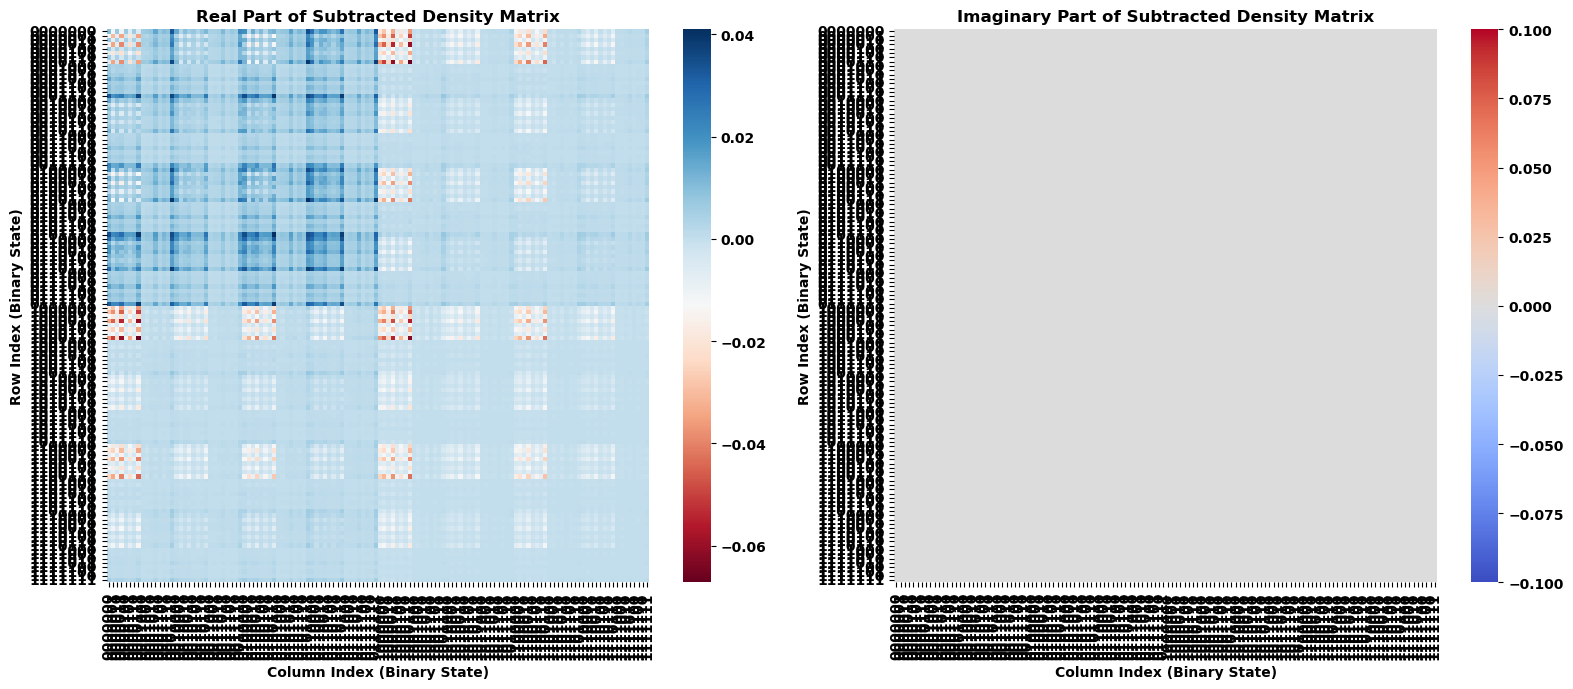

In [234]:
np.random.seed(42) 

print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)
    
#best_cnot_sequence, min_kl_sum, all_possible_single_cnots, working_pool = find_best_cnot_sequence_iterative_pairwise(
all_possible_single_cnots, best_cnot_sequence, best_remove_sequence, min_kl_sum = find_best_cnot_sequence_iterative_pairwise(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold= 0 # 0.4 
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")

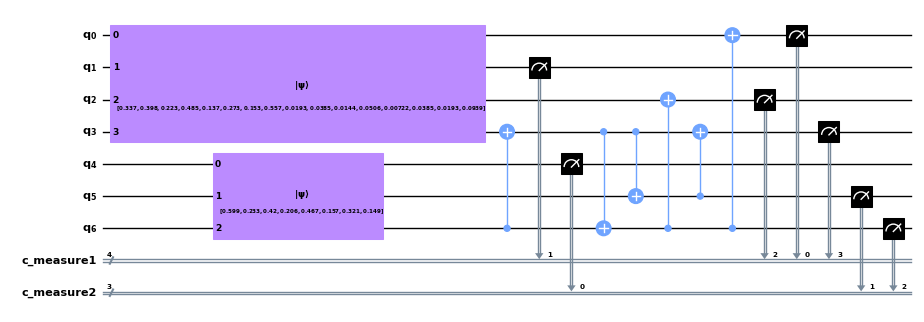

In [231]:
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)

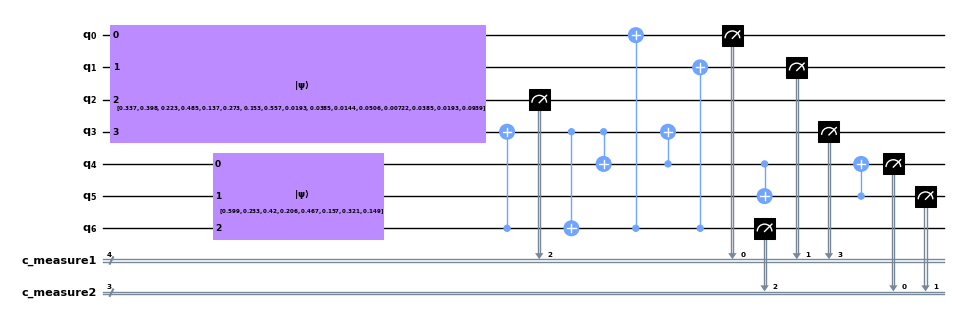

In [222]:
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)


--- Simulating and Plotting Histograms for: CNOT Optimized Circuit ---
Counts for c_measure1: {'0011': 312, '0100': 33, '0000': 150, '1111': 214, '1011': 167, '0001': 206, '0111': 435, '0010': 65, '1001': 109, '0101': 104, '1010': 34, '1100': 10, '1101': 58, '1000': 69, '0110': 20, '1110': 14}
Counts for c_measure2: {'000': 921, '010': 799, '011': 131, '001': 128, '110': 11, '100': 9, '101': 1}


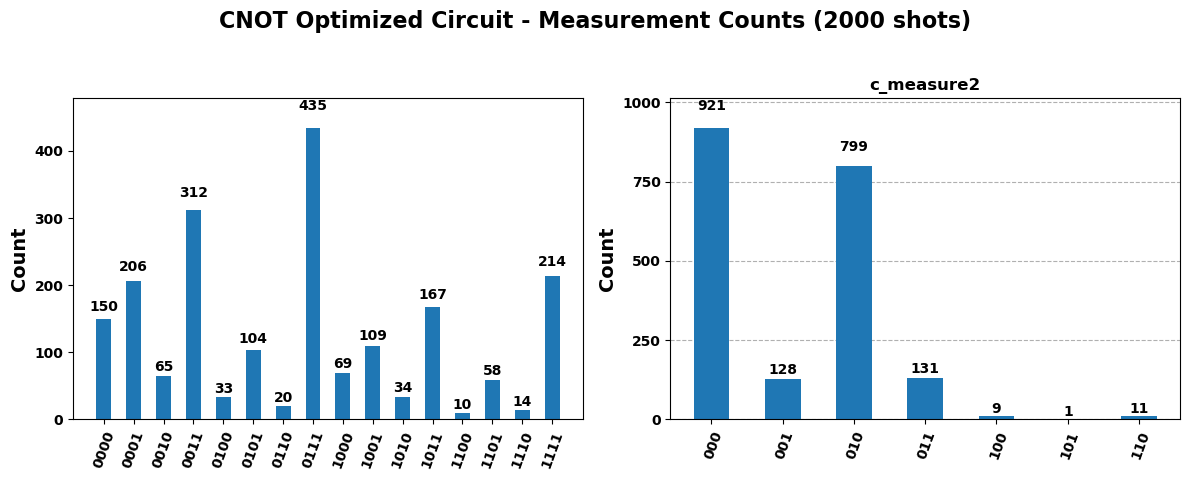

In [232]:
# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=2000, title_prefix="CNOT Optimized Circuit")

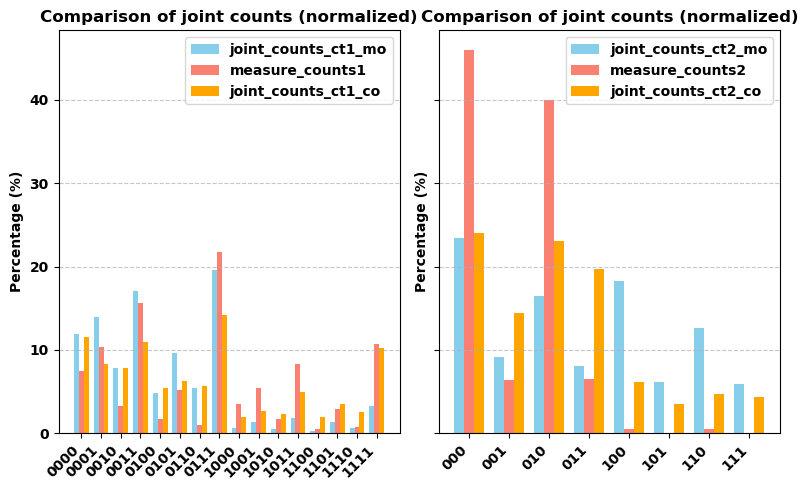

In [233]:
import matplotlib.pyplot as plt
import numpy as np

# Function to normalize dictionary values to percentages
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize all the data dictionaries
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)


# Combine normalized data for each subplot
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# Create a figure with a 1x2 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5), sharey=True)

# Loop through the two columns to create the plots
for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Get all unique keys for proper alignment
    all_keys = sorted(list(set(current_data[0].keys()) | set(current_data[1].keys()) | set(current_data[2].keys())))
    x = np.arange(len(all_keys))
    width = 0.25  # Bar width
    
    # Plot bars for the three datasets
    values1 = [current_data[0].get(key, 0) for key in all_keys]
    values2 = [current_data[1].get(key, 0) for key in all_keys]
    values3 = [current_data[2].get(key, 0) for key in all_keys]

    axes[i].bar(x - width, values1, width, label=current_titles[0], color='skyblue')
    axes[i].bar(x, values2, width, label=current_titles[1], color='salmon')
    axes[i].bar(x + width, values3, width, label=current_titles[2], color='orange')
    
    # Set labels, title, and legend
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=45, ha='right')
    axes[i].set_title(f'Comparison of joint counts (normalized)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('normalized_counts.png')



--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (8 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['2.5955', '2.7190', '1.5236', '2.7315', '1.4766', '1.5538', '1.6063', '1.5157']
CRX Angle Optimization took: 18.23 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['2.5955', '2.7190', '1.5236', '2.7315', '1.4766', '1.5538', '1.6063', '1.5157']
  Minimum Combined KL Divergence with Optimized CRX: 0.204799


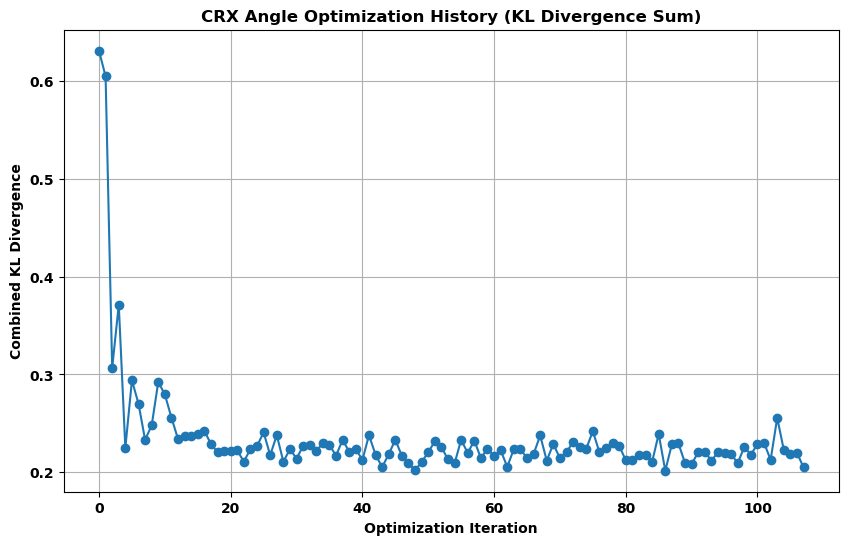


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
c_measure1: 4/»
              »
c_measure2: 3/»
              »
«              ┌──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«         q_0: ┤0                                                                                                                                                     ├»
«              │                                                                                                                                                      │»
«         q_1: ┤1                                                                                                                              

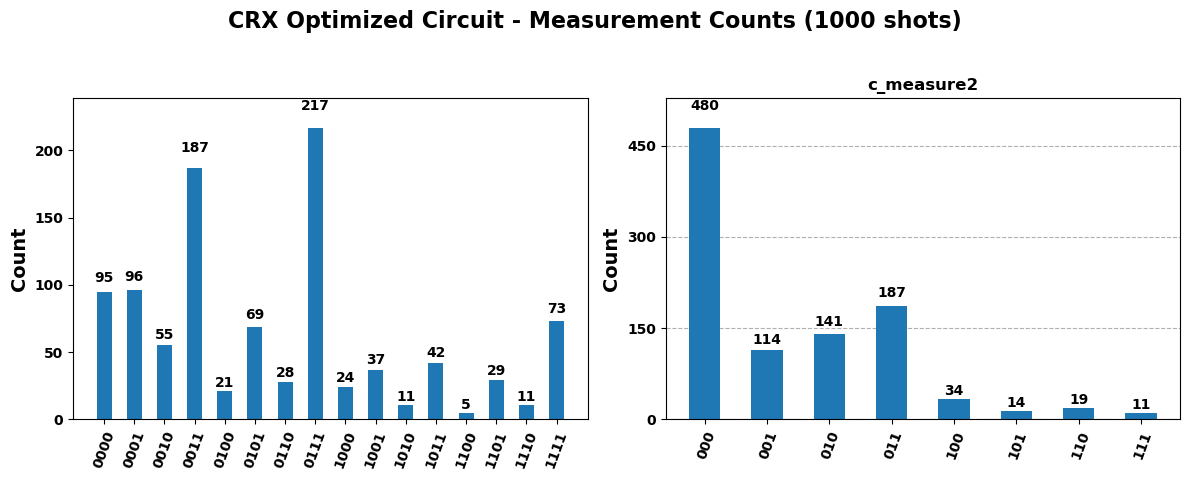

({'0000': 95,
  '0011': 187,
  '0001': 96,
  '1101': 29,
  '0010': 55,
  '0111': 217,
  '0101': 69,
  '1001': 37,
  '1110': 11,
  '1011': 42,
  '1111': 73,
  '1100': 5,
  '1010': 11,
  '0110': 28,
  '1000': 24,
  '0100': 21},
 {'000': 480,
  '011': 187,
  '010': 141,
  '110': 19,
  '001': 114,
  '100': 34,
  '101': 14,
  '111': 11})

In [221]:
# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)
optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    best_cnot_sequence, # Use the CNOT topology found by brute-force
    nshots=5000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= np.pi/2 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
plot_measurement_histograms(final_crx_optimized_circuit, nshots=1000, title_prefix="CRX Optimized Circuit")


--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (32 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['0.0773', '1.1179', '0.9785', '0.9389', '1.0411', '0.0000', '0.0000', '0.0139', '0.1906', '0.0732', '0.0000', '0.1176', '0.0557', '0.8467', '0.0819', '0.1459', '0.8711', '0.0767', '1.0285', '0.0022', '0.0000', '0.0000', '0.0000', '0.0643', '0.0000', '0.0082', '0.0082', '0.0562', '0.0682', '0.0000', '0.0000', '0.0340']
CRX Angle Optimization took: 74.09 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['0.0773', '1.1179', '0.9785', '0.9389', '1.0411', '0.0000', '0.0000', '0.0139', '0.1906', '0.0732', '0.0000', '0.1176', '0.0557', '0.8467', '0.0819', '0.1459', '0.8711', '0.0767', '1.0285', '0.0022', '0.0000', '0.0000', '0.0000', '0.0643', '0.0000', '0.0082', '0.0082', '0.0562', '0.0682', '0.0000', '0.0000', '0.0340']
  Minimum Combined KL Divergence 

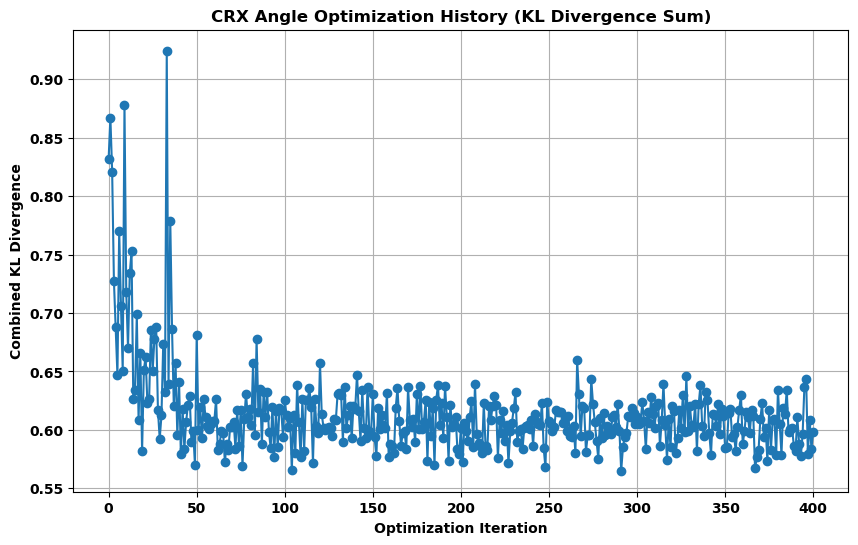


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
c_measure1: 4/»
              »
c_measure2: 3/»
              »
«              ┌──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«         q_0: ┤0                                                                                                                                                     ├»
«              │                                                                                                                                                      │»
«         q_1: ┤1                                                                                                                              

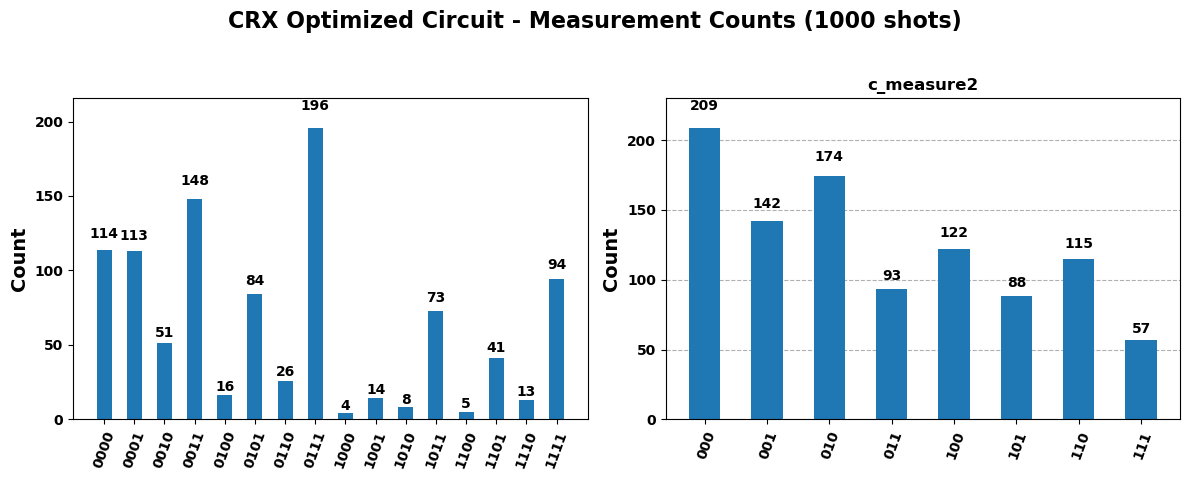

({'0111': 196,
  '0000': 114,
  '0110': 26,
  '1011': 73,
  '0101': 84,
  '0011': 148,
  '1111': 94,
  '0001': 113,
  '1110': 13,
  '1101': 41,
  '0010': 51,
  '1100': 5,
  '1000': 4,
  '1010': 8,
  '0100': 16,
  '1001': 14},
 {'001': 142,
  '110': 115,
  '000': 209,
  '010': 174,
  '100': 122,
  '011': 93,
  '101': 88,
  '111': 57})

In [207]:
# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)
optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    best_remove_sequence, # Use the CNOT topology found by brute-force
    nshots=5000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= 0 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_remove_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
plot_measurement_histograms(final_crx_optimized_circuit, nshots=1000, title_prefix="CRX Optimized Circuit")

In [18]:
import time
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix

# Assuming all helper functions (_process_target_state_input, etc.) are defined.

def build_kl_divergence_matrix_for_qaoa(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_probs_initial1: dict,
    state_probs_initial2: dict,
    state_vec_probs_target1: dict,
    state_vec_probs_target2: dict,
    nshots: int = 1000,
    threshold: float = 0.05,
    include_single_cnot_kl: bool = True
):
    """
    Builds a matrix where M[i][j] represents the KL divergence of the circuit
    formed by cnot_i followed by cnot_j.
    
    This function first identifies potential CNOT candidates by analyzing
    the density matrix difference between the initial and target states,
    and then calculates the KL divergence for single CNOTs and all CNOT pairs.

    Args:
        circ1 (QuantumCircuit): The first base quantum circuit.
        circ2 (QuantumCircuit): The second base quantum circuit.
        state_probs_initial1 (dict): Initial state probabilities for circ1.
        state_probs_initial2 (dict): Initial state probabilities for circ2.
        state_vec_probs_target1 (dict): Target state probabilities for circ1's part.
        state_vec_probs_target2 (dict): Target state probabilities for circ2's part.
        nshots (int): Number of shots for circuit simulation.
        threshold (float): Threshold to identify significant off-diagonal elements.
        include_single_cnot_kl (bool): If True, the diagonal M[i][i] will store
                                       the KL divergence of the circuit with only cnot_i.

    Returns:
        np.ndarray: A square matrix where M[i][j] is the KL divergence for
                    the sequence [cnot_i, cnot_j].
        dict: A mapping from CNOT tuple to its index in the matrix.
        list: The list of initial CNOT candidates used.
        float: The initial KL divergence for the circuit with no CNOTs.
    """
    ng_circ1 = circ1.num_qubits
    
    print(f"\n--- Identifying Potential CNOT Linkers from Density Matrix Difference ---")

    state_list1_initial, _ = _process_target_state_input(state_probs_initial1)
    state_list2_initial, _ = _process_target_state_input(state_probs_initial2)
    state_list1_target, _ = _process_target_state_input(state_vec_probs_target1)
    state_list2_target, _ = _process_target_state_input(state_vec_probs_target2)

    combined_state_amplitudes0 = np.kron(state_list2_initial, state_list1_initial)
    combined_state_amplitudes = np.kron(state_list2_target, state_list1_target)
    sv0 = Statevector(combined_state_amplitudes0)
    sv = Statevector(combined_state_amplitudes)
    dm0 = DensityMatrix(sv0)
    dm = DensityMatrix(sv)
    diff = dm - dm0
    matrix_data = diff.data

    row_indices, col_indices = np.where(matrix_data > threshold)
    row_indices0, col_indices0 = np.where(matrix_data < -threshold)

    dim = matrix_data.shape[0]
    labels = [bin(i)[2:].zfill(int(np.log2(dim))) for i in range(dim)]
    active_labels = set(labels[i] for i in row_indices) | set(labels[i] for i in col_indices)
    active_labels0 = set(labels[i] for i in row_indices0) | set(labels[i] for i in col_indices0)

    all_cnot_configurations = set()
    for ibit_string in active_labels0:
        for jbit_string in active_labels:
            i_locs = [len(ibit_string) - 1 - i for i, bit in enumerate(ibit_string) if bit == '1']
            j_locs = [len(jbit_string) - 1 - i for i, bit in enumerate(jbit_string) if bit == '1']
            all_cnot_configurations.update(create_cnot_pairs_from_locations(i_locs, j_locs))
    initial_cnot_config = sorted(list(all_cnot_configurations))

    print(f"Number of potential CNOT candidates found: {len(initial_cnot_config)}")
    
    # --- Calculate Baseline KL Divergence (no CNOTs) ---
    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit_no_cnots = add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, [])
    kl_divs_baseline = score_circuit_kl_divergences(base_circuit_no_cnots, state_vec_probs_target1, state_vec_probs_target2, nshots)
    initial_kl_sum = kl_divs_baseline[0] + kl_divs_baseline[1] if kl_divs_baseline is not None else float('inf')
    print(f"Initial KL Divergence (no CNOTs): {initial_kl_sum:.6f}")

    # --- Start building the matrix with the identified candidates ---
    num_candidates = len(initial_cnot_config)
    kl_divergence_matrix = np.full((num_candidates, num_candidates), np.inf)
    cnot_to_index = {tuple(cnot): i for i, cnot in enumerate(initial_cnot_config)}

    print(f"\n--- Building KL Divergence Matrix ({num_candidates}x{num_candidates}) ---")

    if include_single_cnot_kl:
        print("Calculating KL for single CNOTs (diagonal elements)...")
        for i, cnot_i in enumerate(initial_cnot_config):
            trial_circuit = add_cnots_and_measurements_to_circuit(
                base_combined_circuit, ng_circ1, [cnot_i]
            )
            kl_divs = score_circuit_kl_divergences(
                trial_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots
            )
            if kl_divs is not None:
                kl_divergence_matrix[i, i] = kl_divs[0] + kl_divs[1]
                # print(f"  KL for [{cnot_i}]: {kl_divergence_matrix[i, i]:.6f}")

    print("Calculating KL for CNOT pairs (off-diagonal elements)...")
    n_pairs_tested = 0
    for cnot_i_val in initial_cnot_config:
        for cnot_j_val in initial_cnot_config:
            idx_i = cnot_to_index[tuple(cnot_i_val)]
            idx_j = cnot_to_index[tuple(cnot_j_val)]

            if idx_i == idx_j:
                continue

            n_pairs_tested += 1
            trial_sequence = [cnot_i_val, cnot_j_val]
            trial_circuit = add_cnots_and_measurements_to_circuit(
                base_combined_circuit, ng_circ1, trial_sequence
            )
            kl_divs = score_circuit_kl_divergences(
                trial_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots
            )
            if kl_divs is not None:
                kl_divergence_matrix[idx_i, idx_j] = kl_divs[0] + kl_divs[1]
                # print(f"  KL for [{cnot_i_val}, {cnot_j_val}]: {kl_divergence_matrix[idx_i, idx_j]:.6f}")
    
    print(f"Total CNOT pairs tested: {n_pairs_tested}")
    print("--- KL Divergence Matrix Built ---")

    return kl_divergence_matrix, cnot_to_index, initial_cnot_config, initial_kl_sum

In [20]:
np.random.seed(42) 

print("\n" + "="*40)
print("--- Creating QUBO matrix ---")
print("="*40)
    
kl_divergence_matrix, cnot_to_index, initial_cnot_config, initial_kl_sum = build_kl_divergence_matrix_for_qaoa(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold= 0.01, 
    include_single_cnot_kl=True
)



--- Creating QUBO matrix ---

--- Identifying Potential CNOT Linkers from Density Matrix Difference ---
Number of potential CNOT candidates found: 42
Initial KL Divergence (no CNOTs): 0.850655

--- Building KL Divergence Matrix (42x42) ---
Calculating KL for single CNOTs (diagonal elements)...
Calculating KL for CNOT pairs (off-diagonal elements)...
Total CNOT pairs tested: 1722
--- KL Divergence Matrix Built ---


In [24]:
import numpy as np

def build_kl_qubo_paulis(kl_matrix: np.ndarray, initial_kl_sum: float) -> list[tuple[str, list[int], float]]:
    """
    Builds a Pauli list from a KL divergence matrix, with symmetrized
    quadratic interaction costs and a baseline subtraction.
    
    The costs are now calculated to represent the change in KL divergence
    relative to the initial KL divergence of the zero-CNOT circuit.

    Args:
        kl_matrix (np.ndarray): The matrix where kl_matrix[k, k] is the KL divergence
                                for a single CNOT k, and kl_matrix[k, l] is for the
                                sequence [CNOT k, CNOT l].
        initial_kl_sum (float): The baseline KL divergence with no CNOTs.

    Returns:
        list[tuple[str, list[int], float]]: The Pauli list in the format
                                             [('Pauli_string', [qubits], weight), ...].
    """
    num_qubits = kl_matrix.shape[0]
    pauli_list = []
    
    print("--- Deriving Pauli List from KL Divergence Matrix (with baseline subtraction) ---")

    # Define a large penalty for undefined KL values
    INF_PENALTY = 1e9

    # Build the linear coefficients for each CNOT (x_k)
    linear_coeffs = np.full(num_qubits, INF_PENALTY)
    for k in range(num_qubits):
        A_k_abs = kl_matrix[k, k]
        if not np.isinf(A_k_abs):
            linear_coeffs[k] = A_k_abs
        else:
            print(f"Warning: Single CNOT {k} has infinite KL. Assigning large penalty.")
            
    # Build the quadratic coefficients for each CNOT pair (x_k x_l)
    quadratic_coeffs = np.full((num_qubits, num_qubits), 0.0)
    for k in range(num_qubits):
        for l in range(k + 1, num_qubits):
            kl_kl = kl_matrix[k, l]
            kl_lk = kl_matrix[l, k]

            if not np.isinf(kl_kl) and not np.isinf(kl_lk):
                symmetrized_kl_pair = (kl_kl + kl_lk) / 2
                
                # B_kl is the quadratic interaction term.
                # It's the pair cost minus the individual costs.
                B_kl = symmetrized_kl_pair - linear_coeffs[k] - linear_coeffs[l]
                quadratic_coeffs[k, l] = B_kl
                
            else:
                # If KL is undefined, the interaction is penalized
                B_kl = INF_PENALTY
                quadratic_coeffs[k, l] = B_kl

    # Combine coefficients to form the Pauli list
    # The total cost function is H = sum(A_k*x_k) + sum(B_kl*x_k*x_l)
    # The Pauli terms are derived from this.

    # 1. Linear Pauli terms (from x_k and x_k*x_l)
    for k in range(num_qubits):
        # Contribution from A_k*x_k
        zk_coeff = -linear_coeffs[k] / 2.0
        
        # Contribution from B_kj*x_k*x_j for j != k
        for j in range(num_qubits):
            if k == j:
                continue
            zk_coeff -= quadratic_coeffs[min(k,j), max(k,j)] / 4.0
        
        if zk_coeff != 0:
            pauli_list.append(("Z", [k], zk_coeff))

    # 2. Quadratic Pauli terms (from B_kl*x_k*x_l)
    for k in range(num_qubits):
        for l in range(k + 1, num_qubits):
            zz_coeff = quadratic_coeffs[k, l] / 4.0
            if zz_coeff != 0:
                pauli_list.append(("ZZ", [k, l], zz_coeff))

    # 3. Constant term (sum of all constant offsets)
    constant_offset = 0.0
    for k in range(num_qubits):
        constant_offset += linear_coeffs[k] / 2.0
    for k in range(num_qubits):
        for l in range(k + 1, num_qubits):
            constant_offset += quadratic_coeffs[k, l] / 4.0
            
    # Add the initial KL sum as a negative constant to shift the energy landscape.
    # The QAOA will find the ground state of this Hamiltonian.
    # The energy of the 0-CNOT solution should be `initial_kl_sum`.
    pauli_list.append(("I", [0], constant_offset - initial_kl_sum))

    print("--- Pauli List Created ---")
    return pauli_list

In [25]:
from qiskit.quantum_info import SparsePauliOp
n = kl_divergence_matrix.shape[0]
max_cut_paulis = build_kl_qubo_paulis(kl_divergence_matrix, initial_kl_sum)
cost_hamiltonian = SparsePauliOp.from_sparse_list(max_cut_paulis, n)
print("Cost Function Hamiltonian:", cost_hamiltonian)

--- Deriving Pauli List from KL Divergence Matrix (with baseline subtraction) ---
--- Pauli List Created ---
Cost Function Hamiltonian: SparsePauliOp(['...'],
              coeffs=[ 8.71174977e+00+0.j,  8.41844045e+00+0.j,  8.04420563e+00+0.j,
  8.38948723e+00+0.j,  8.29365134e+00+0.j,  8.13157323e+00+0.j,
  8.81701101e+00+0.j,  8.27446628e+00+0.j,  8.00790803e+00+0.j,
  8.16650195e+00+0.j,  8.26433389e+00+0.j,  8.67804784e+00+0.j,
  8.69079342e+00+0.j,  8.68799523e+00+0.j,  7.76493997e+00+0.j,
  8.52203987e+00+0.j,  8.41526079e+00+0.j,  8.20846205e+00+0.j,
  7.58452866e+00+0.j,  7.96268487e+00+0.j,  8.16880130e+00+0.j,
  8.14276817e+00+0.j,  8.11392204e+00+0.j,  8.54343474e+00+0.j,
  7.94823508e+00+0.j,  8.52480890e+00+0.j,  8.21953200e+00+0.j,
  7.94359555e+00+0.j,  8.28154602e+00+0.j,  7.89172607e+00+0.j,
  8.33671259e+00+0.j,  8.57004498e+00+0.j,  8.50526930e+00+0.j,
  7.83300418e+00+0.j,  8.19485347e+00+0.j,  8.36698725e+00+0.j,
  8.06282686e+00+0.j,  8.48737949e+00+0.j,  8.656718

In [27]:
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.providers.fake_provider import GenericBackendV2

# Assuming cost_hamiltonian is defined
# Assuming nshots is defined

layers = 2
seed = 42
qaoa_circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=layers)
qaoa_circuit.measure_all()

# 5. Simulate the circuit
generic_backend = GenericBackendV2(n, seed=seed)

pm = generate_preset_pass_manager(
    optimization_level=3, backend=generic_backend, seed_transpiler=seed
)

qaoa_circuit_transpiled = pm.run(qaoa_circuit)
#qaoa_circuit_transpiled.draw("mpl", fold=False, idle_wires=False)


In [ ]:
init_params = np.zeros(2 * layers)

In [33]:
from qiskit_ibm_runtime import QiskitRuntimeService

from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.quantum_info import SparsePauliOp, Statevector, DensityMatrix, Operator
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit.transpiler import Layout

from qiskit_ibm_runtime import (
    Session,
    EstimatorV2 as Estimator,
    SamplerV2 as Sampler,
    EstimatorOptions,
)
from qiskit_ibm_runtime.debug_tools import Neat
from qiskit_aer import AerSimulator

objective_func_vals = []


def cost_func_estimator(
    params: list, ansatz: QuantumCircuit, isa_hamiltonian: SparsePauliOp, estimator: Estimator
) -> float:
    """Compute the cost function value using a parameterized ansatz and an estimator for a given Hamiltonian."""
    if isa_hamiltonian.num_qubits != ansatz.num_qubits:
        isa_hamiltonian = isa_hamiltonian.apply_layout(ansatz.layout)
    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])
    results = job.result()[0]
    cost = results.data.evs
    objective_func_vals.append(cost)
    return cost


def train_qaoa(
    params: list,
    circuit: QuantumCircuit,
    hamiltonian: SparsePauliOp,
    backend: QiskitRuntimeService.backend,
) -> tuple:
    """Optimize QAOA parameters using COBYLA and an estimator on a given backend."""
    with Session(backend=backend) as session:
        options = {"simulator": {"seed_simulator": seed}}
        estimator = Estimator(mode=session, options=options)
        estimator.options.default_shots = 100000

        result = minimize(
            cost_func_estimator,
            params,
            args=(circuit, hamiltonian, estimator),
            method="COBYLA",
            options={"maxiter": 200, "rhobeg": 1, "catol": 1e-3, "tol": 0.0001},
        )
    print(result)
    return result, objective_func_vals


result_qaoa, objective_func_vals = train_qaoa(
    init_params, qaoa_circuit_transpiled, cost_hamiltonian, generic_backend
)

Simulation failed and returned the following error message:
ERROR:  [Experiment 0] a circuit requires more memory than max_memory_mb.


QiskitError: 'ERROR:  [Experiment 0] a circuit requires more memory than max_memory_mb. ,  ERROR: a circuit requires more memory than max_memory_mb.'

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [ ]:
# Get the optimized parameters from the result
opt_params = result_qaoa.x
SHOTS = 10000


def sample_qaoa(opt_params, circuit, backend):

    # Submit the circuit to Sampler
    options = {"simulator": {"seed_simulator": seed}}
    sampler = Sampler(mode=backend, options=options)
    job = sampler.run([(circuit, opt_params)], shots=SHOTS)
    results_sampler = job.result()
    counts_list = results_sampler[0].data.meas.get_counts()
    display(plot_histogram(counts_list, title=f"Max cut with {backend.name}"))

    return counts_list

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(cost_hamiltonian)
ground_energy = min(eigenvalues).real
num_solutions = eigenvalues.tolist().count(ground_energy)
index_solutions = np.where(eigenvalues == ground_energy)[0].tolist()
print(f"The ground energy of the Hamiltonian is {ground_energy}")
print(f"The number of solutions of the problem is {num_solutions}")
print(f"The list of the solutions based on their index is {index_solutions}")